In [40]:
import pandas as pd

# Read complete data to o EDA
CURATED_FOLDER = CURATED_FOLDER = "../data/curated"
path = final_csv = f"{CURATED_FOLDER}/descriptors_and_frequencies/peptides_100.csv"
complete_data = pd.read_csv(path, delimiter=',')
print(complete_data.info())

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_1401/2537158272.py:6: DtypeWarning: Columns (5046,5125,5350,5351,5352,5363) have mixed types. Specify dtype option on import or set low_memory=False.
  complete_data = pd.read_csv(path, delimiter=',')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Columns: 5604 entries, SEQUENCE to mZagreb2
dtypes: bool(2), float64(5092), int64(337), object(173)
memory usage: 68.3+ MB
None


In [41]:
# Drop all variables with missing values.

print("Before:", complete_data.shape)
df_clean = complete_data.dropna(axis=1,  how='all')
print("After:", df_clean.shape)

Before: (1599, 5604)
After: (1599, 5604)


In [42]:
# Remove variables (descriptors, dimer, and trimer frequencies) with a standard deviation less than 0.05

# Columns to exclude from filtering
exclude_cols = ['SEQUENCE', 'μM', 'label']

df = complete_data 

# Select only numeric columns except the excluded ones
numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)

# Keep only those numeric columns with std >= 0.05
filtered_numeric_cols = [col for col in numeric_cols if df[col].std() >= 0.05]

# Add back excluded columns
final_cols = exclude_cols + filtered_numeric_cols

# Create filtered DataFrame
df_filtered = df[final_cols]


print(f"Original shape: {df.shape}")
print(f"Filtered shape: {df_filtered.shape}")
print(df_filtered.iloc[:,:10])


Original shape: (1599, 5604)
Filtered shape: (1599, 849)
                        SEQUENCE      μM  label         A     AATS0Z  \
0                 GLPALISWIKRKRL   596.7      0  0.071429  20.214286   
1           IVPFLLGMVPKLVCLITKKC     7.0      1  0.000000  21.625000   
2     KLKLKLKLKLKLKLKLKLKLKLKLKL     0.3      1  0.000000  18.271511   
3                   ILPILSLIGGLL   180.0      0  0.000000  19.340206   
4            CVKVRVKVGSGVKVRVKVC   590.0      0  0.000000  21.584416   
...                          ...     ...    ...       ...        ...   
1594            GLWDVIKKVASVIGGL    10.2      1  0.062500  20.766129   
1595               IFGAIWSGIKSLF    48.0      1  0.076923  21.228571   
1596         GVIIKKLKGAAKKVAAKLL  1000.0      0  0.210526  19.322581   
1597                ILPIRSLIKKLL   103.4      0  0.000000  19.044248   
1598                GKWMSALKHILK   200.0      0  0.083333  21.626794   

      AATS0are    AATS0d   AATS0dv      AATS0i     AATS0m  
0     6.165368  2.

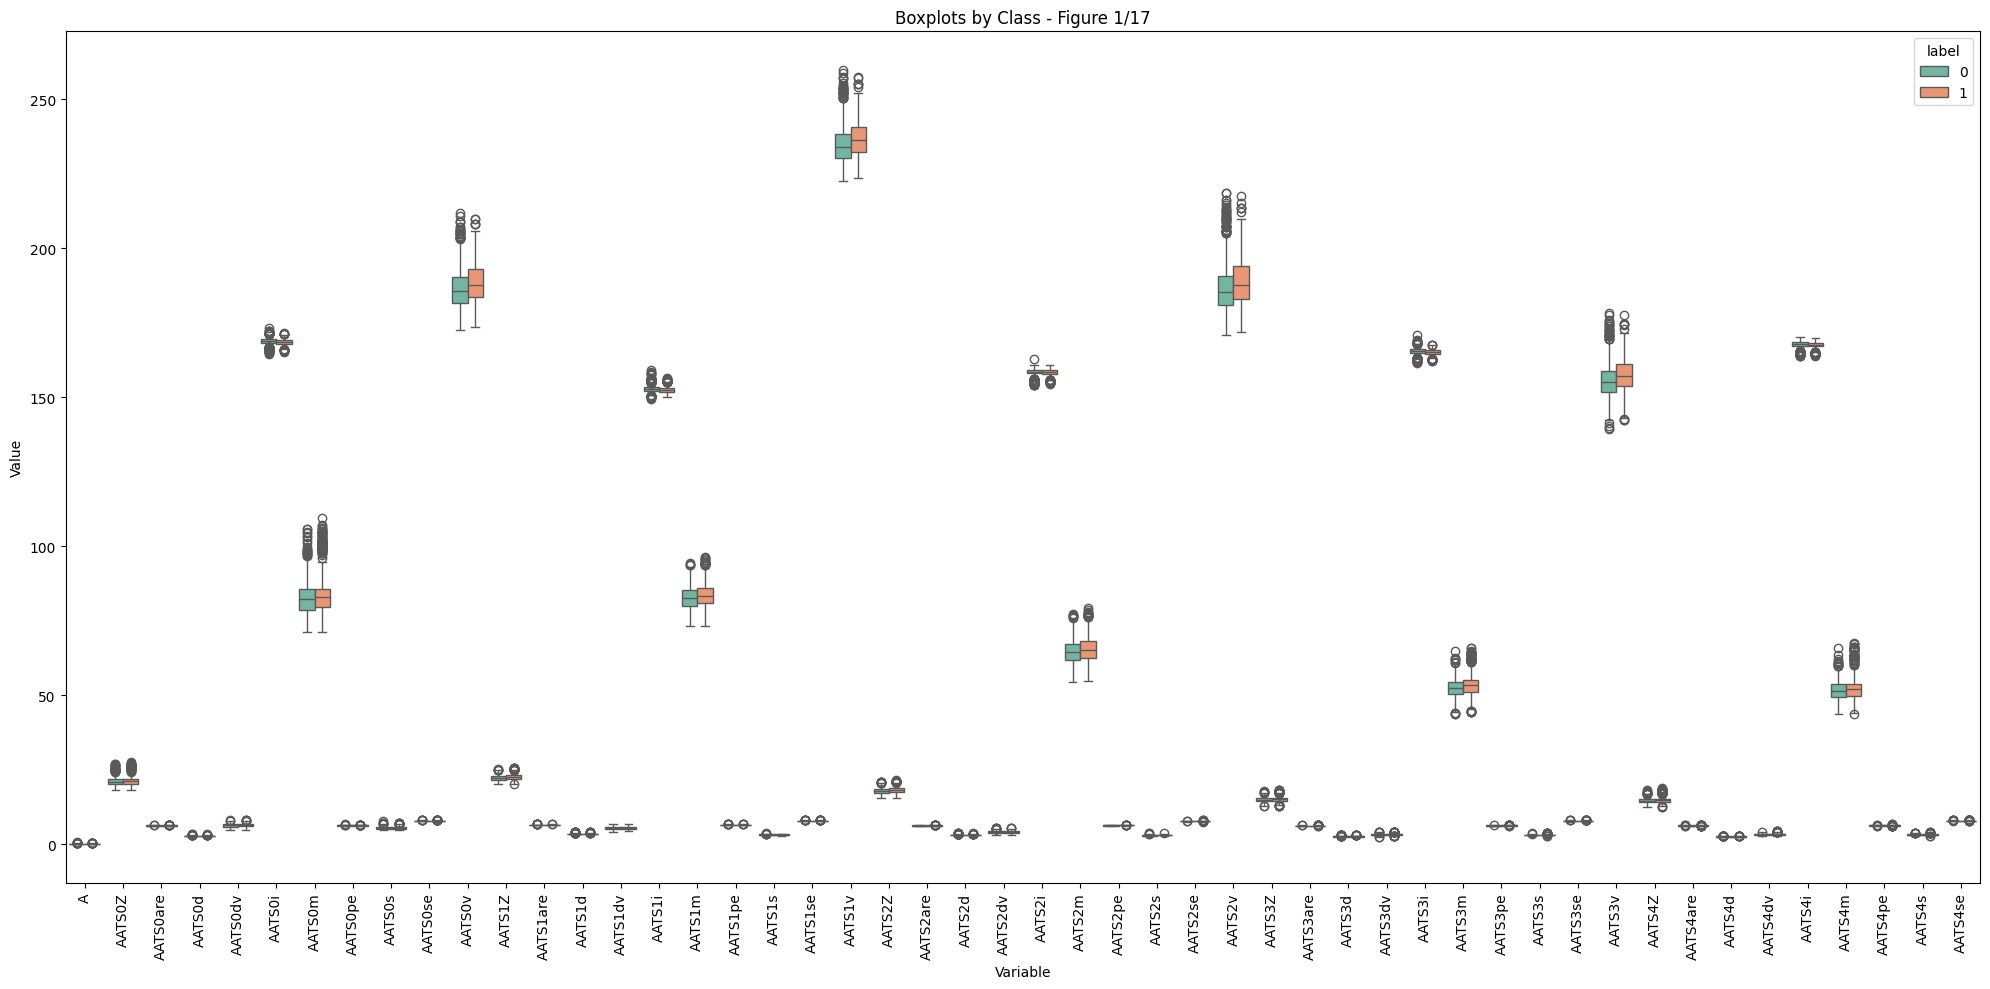

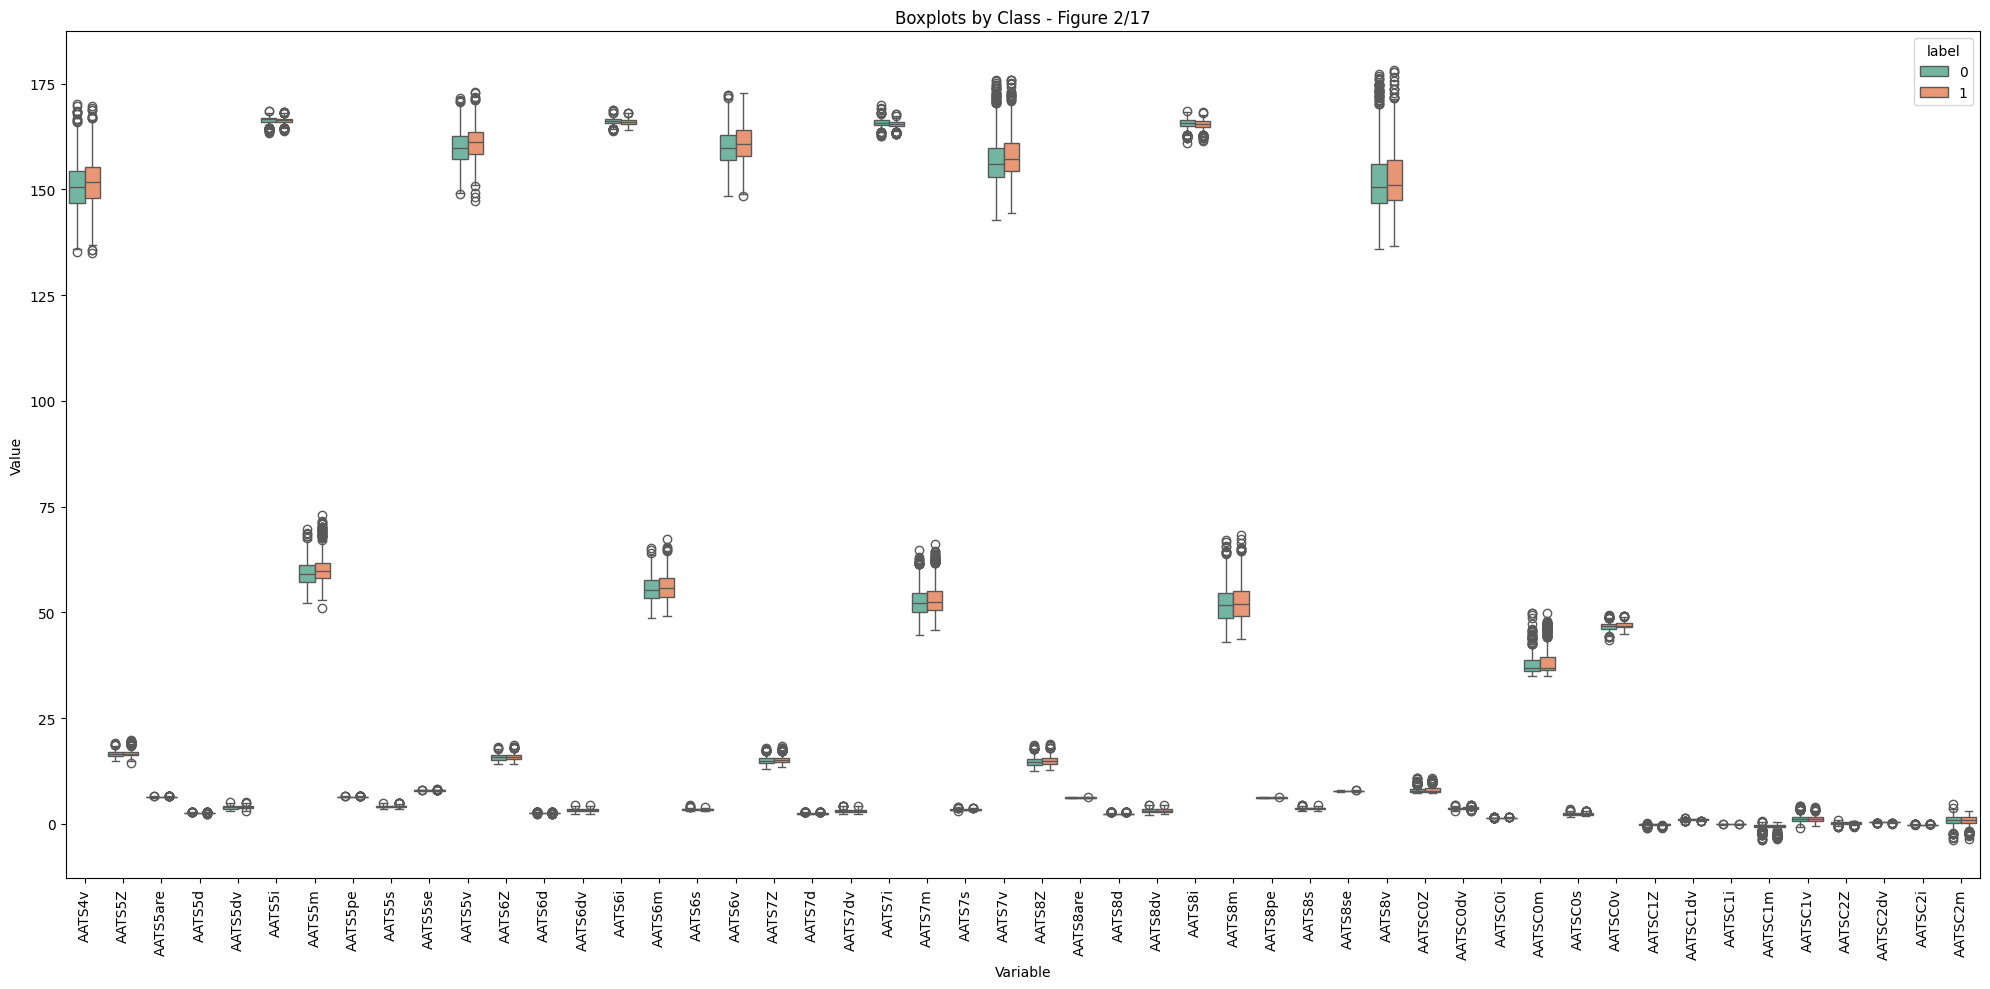

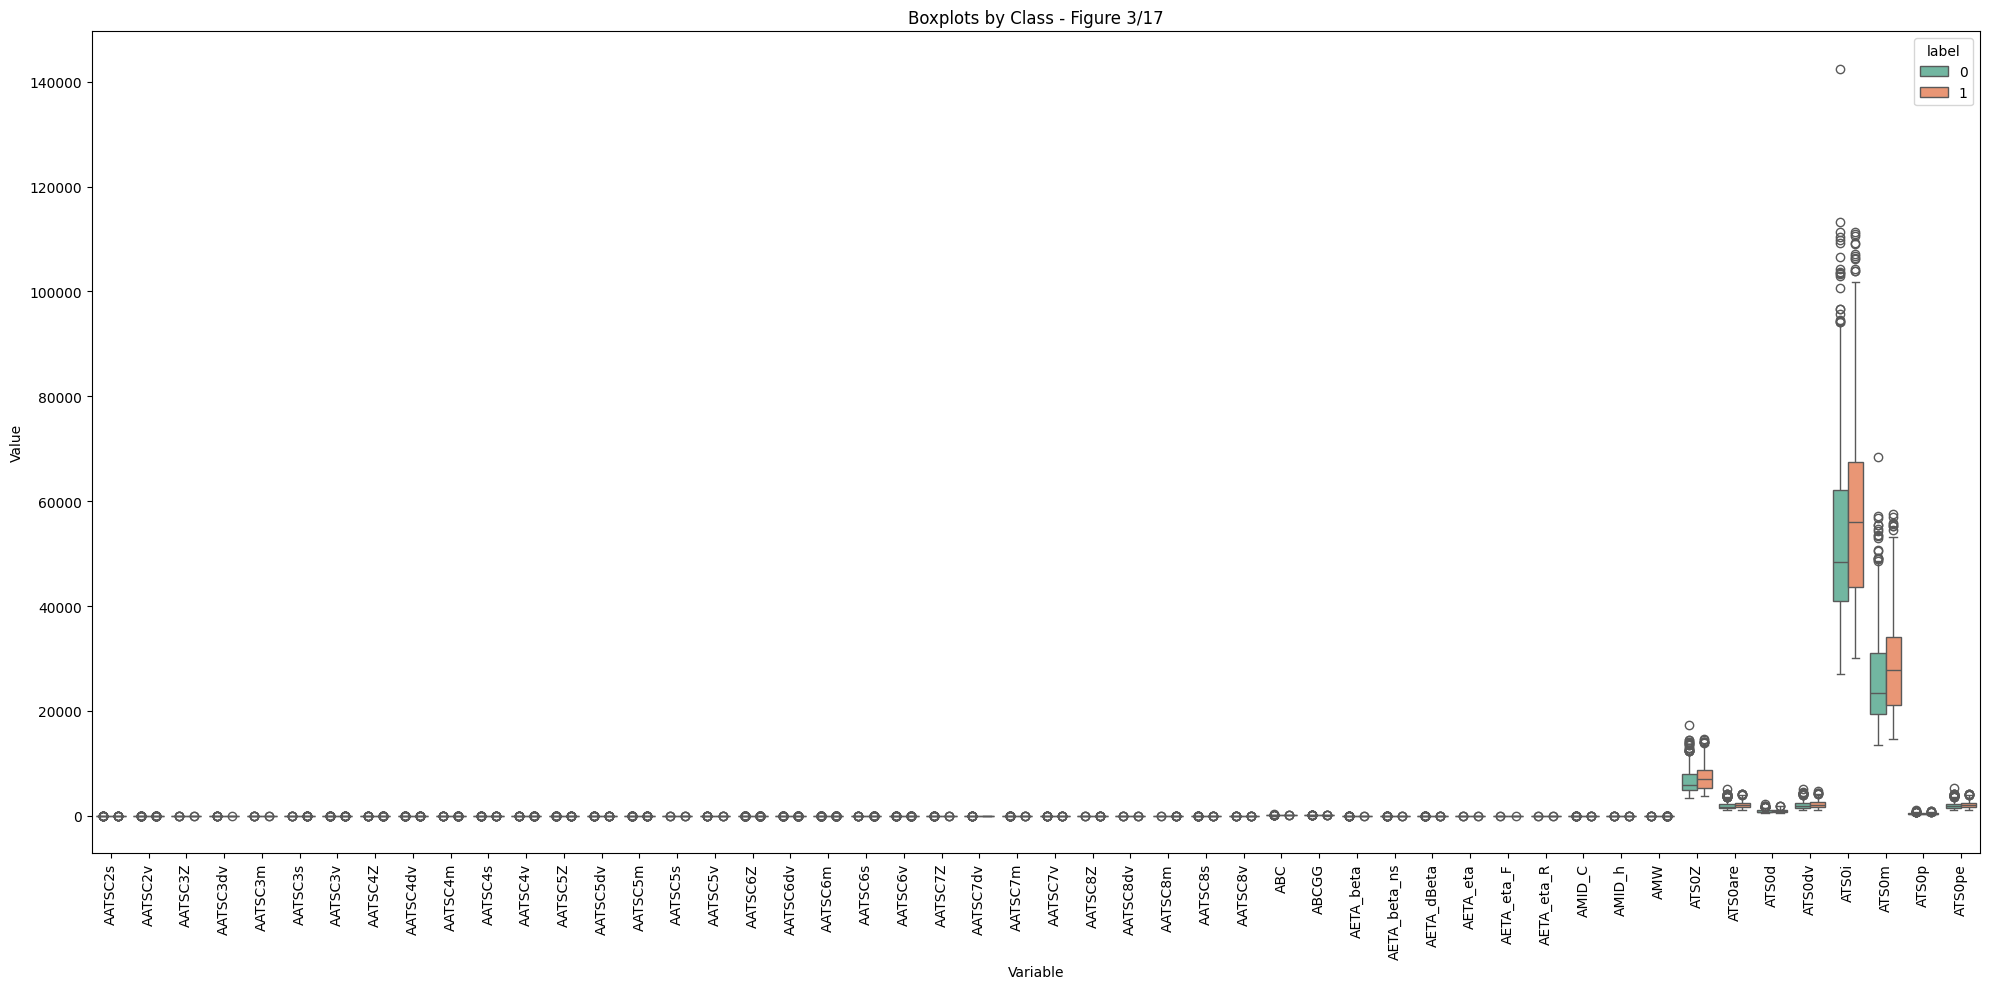

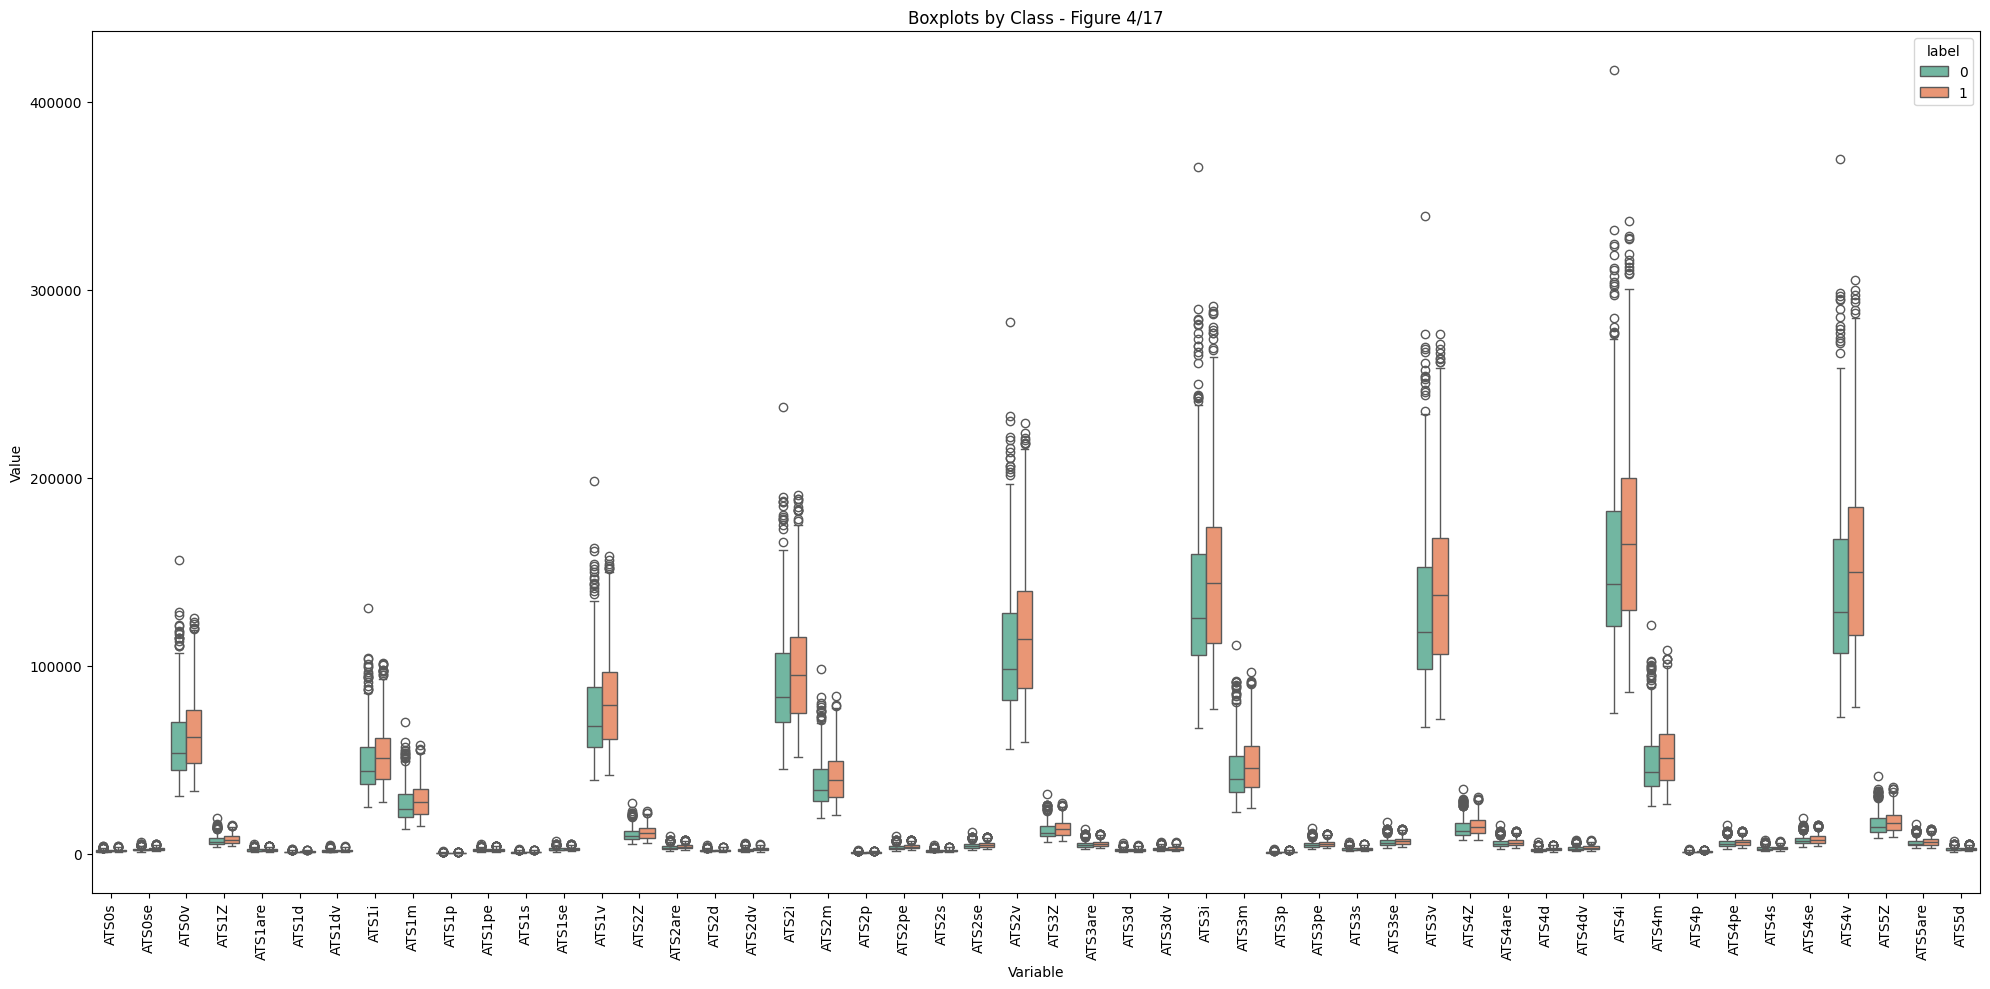

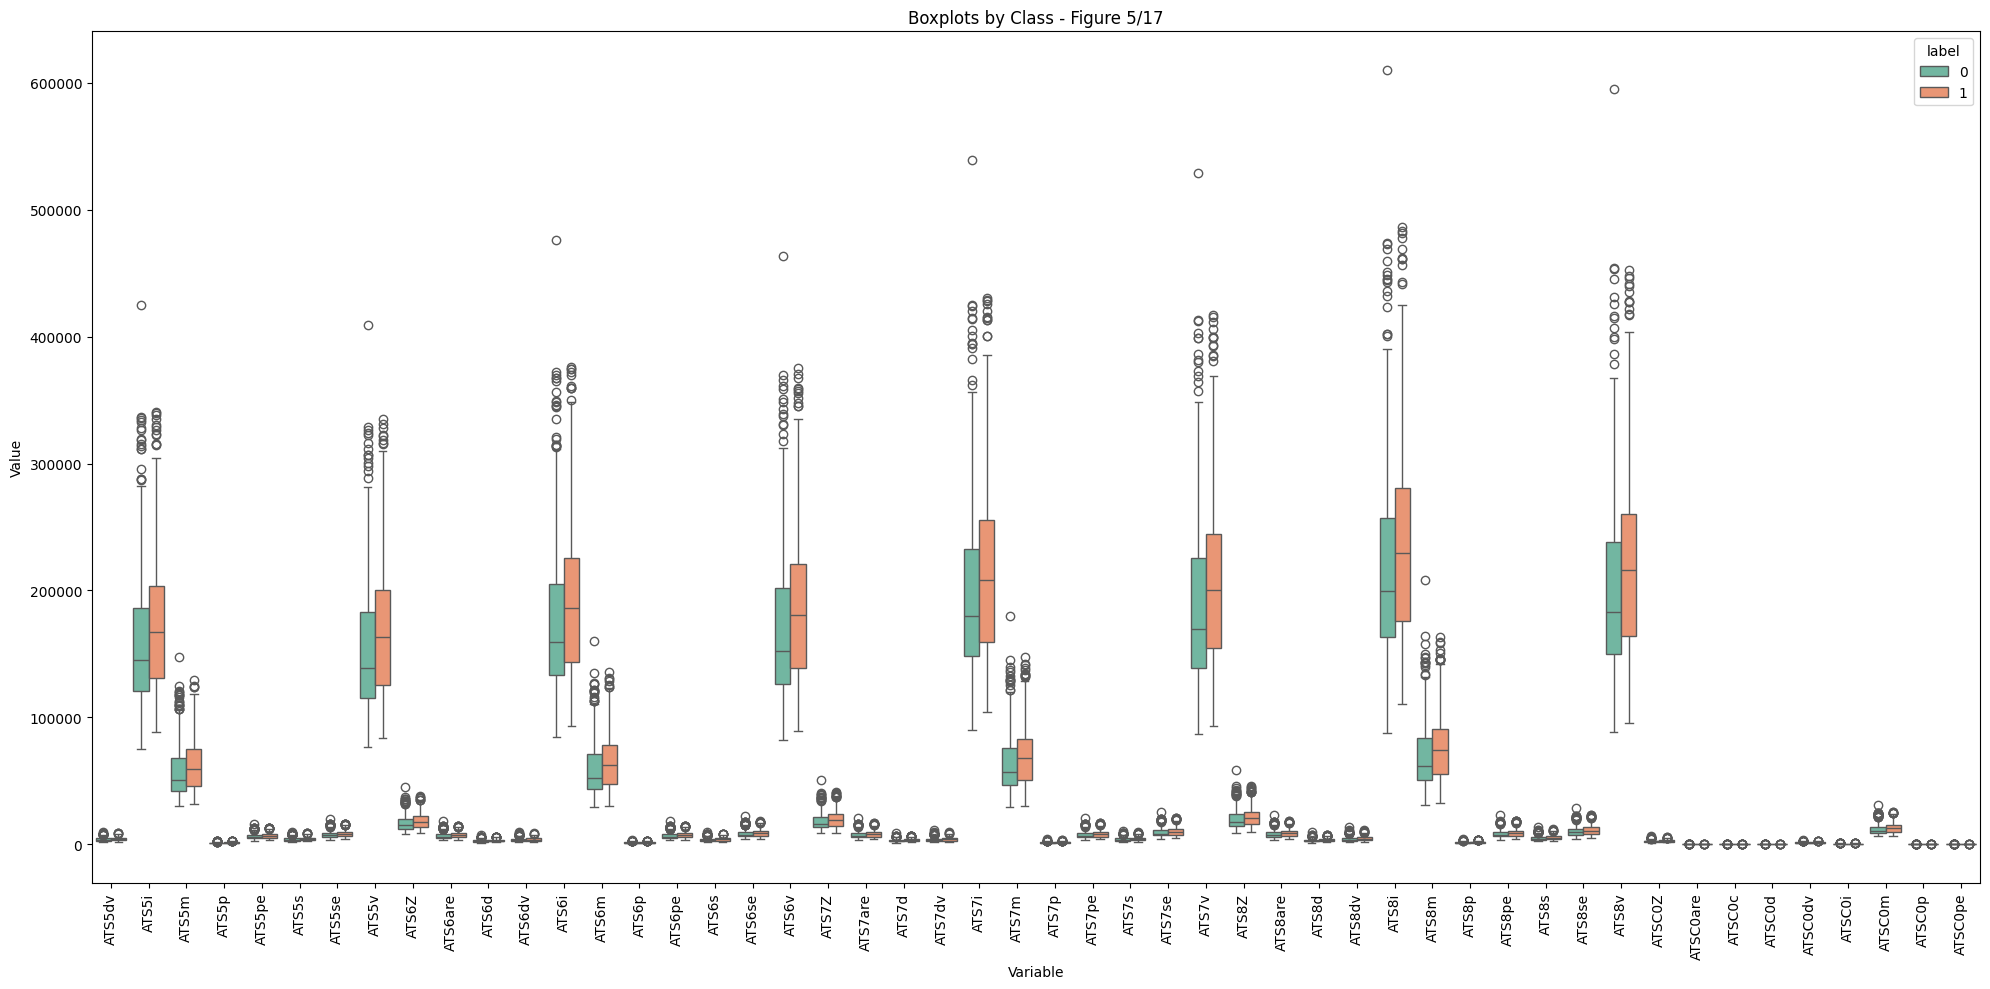

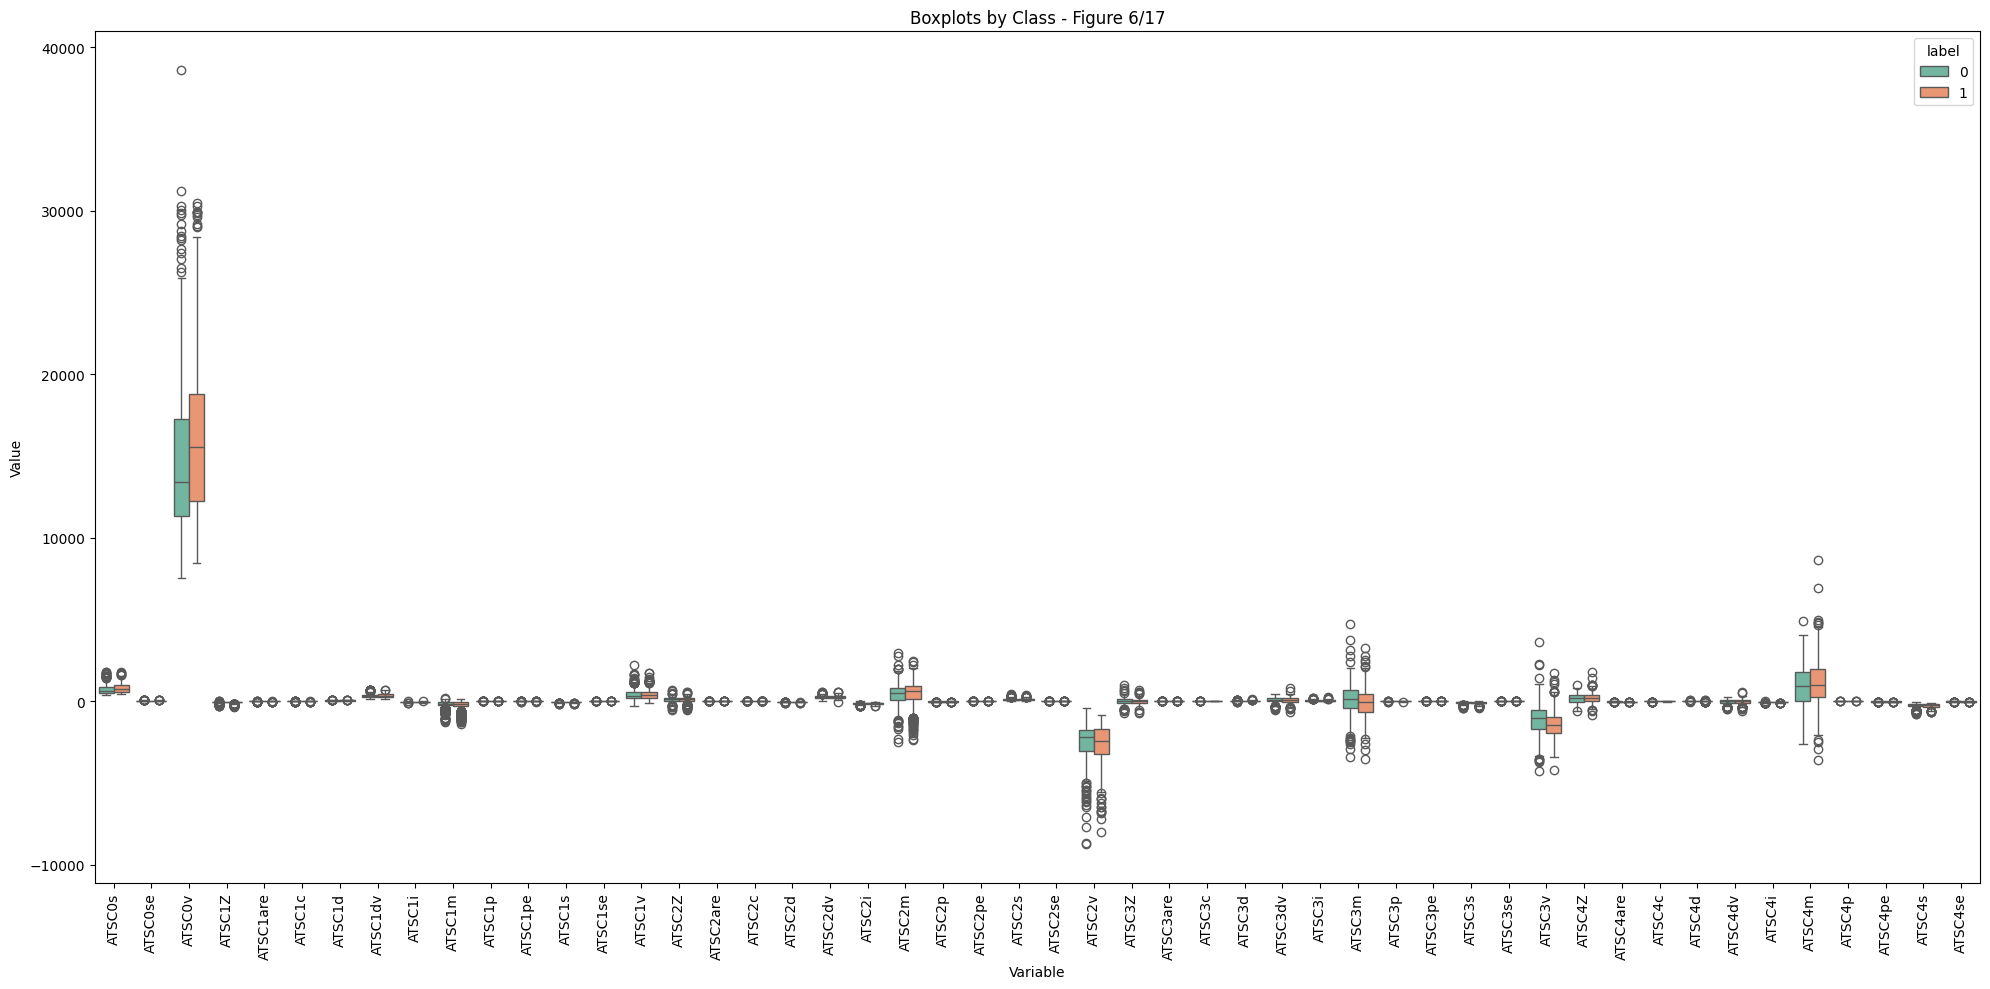

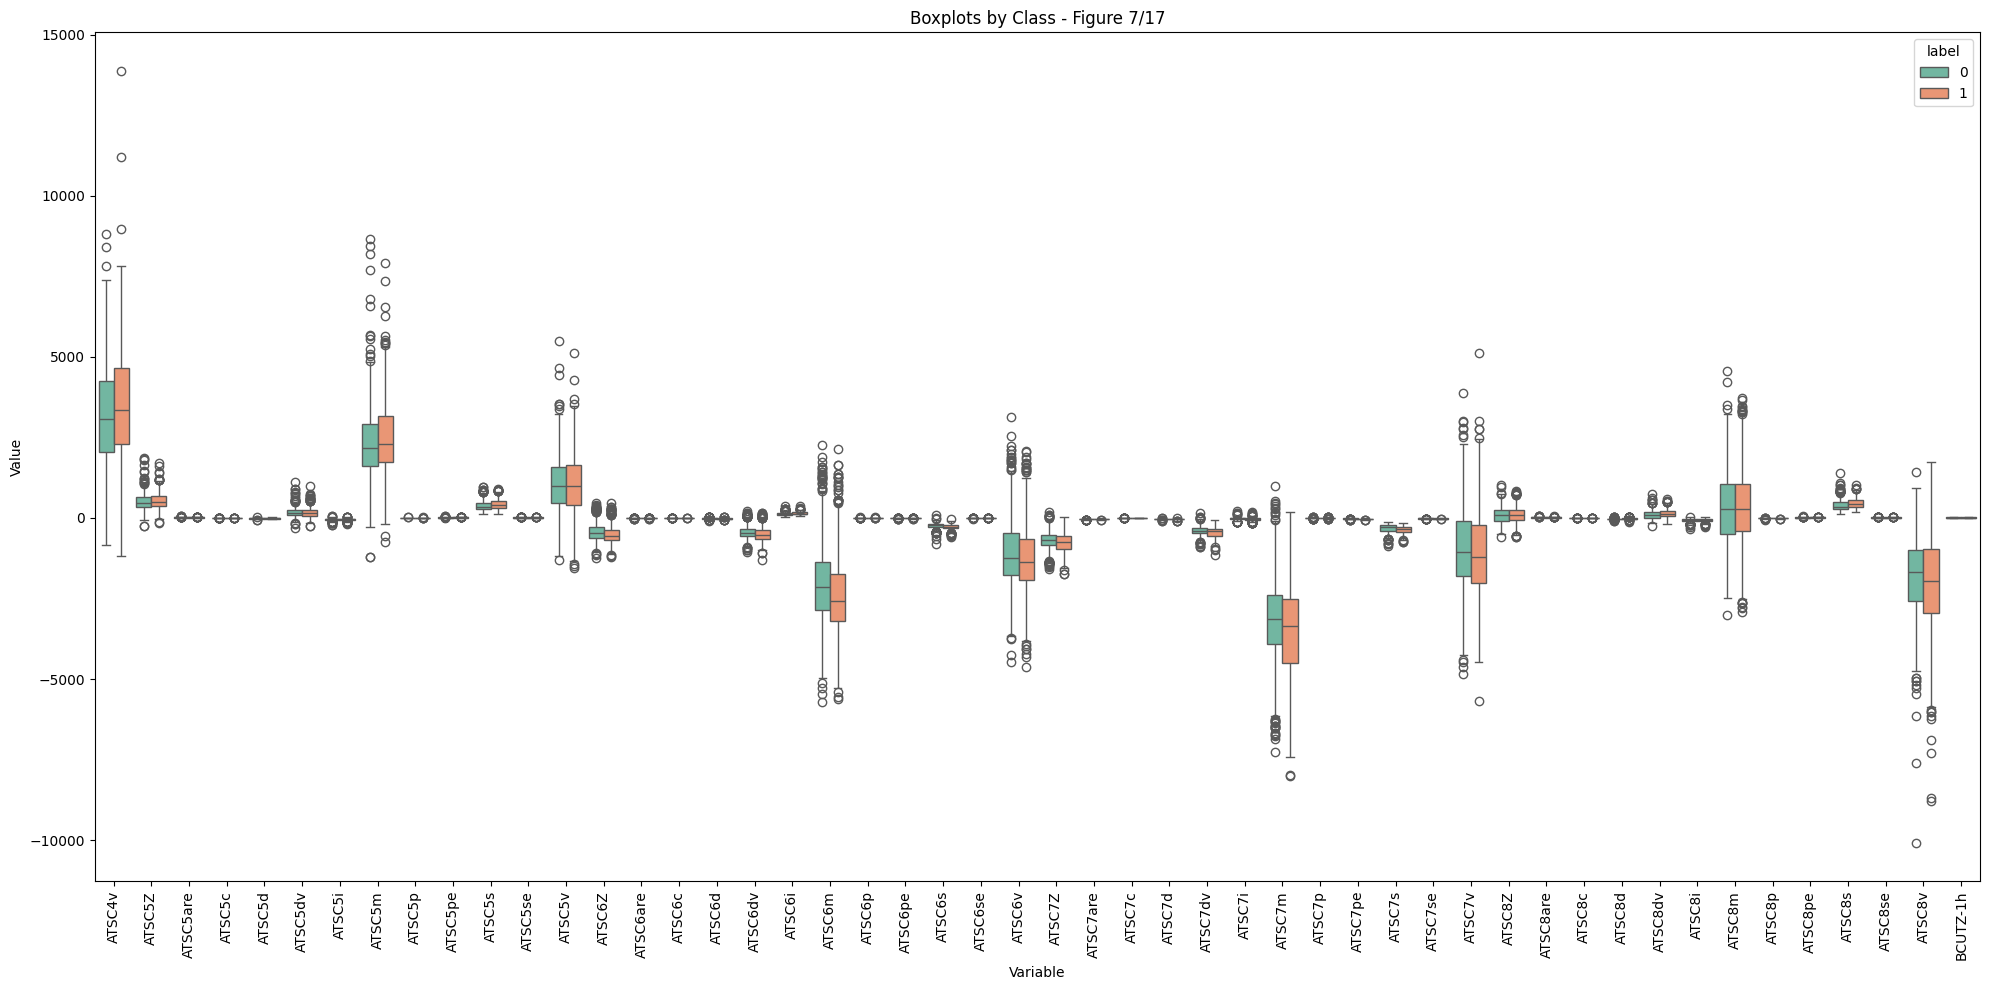

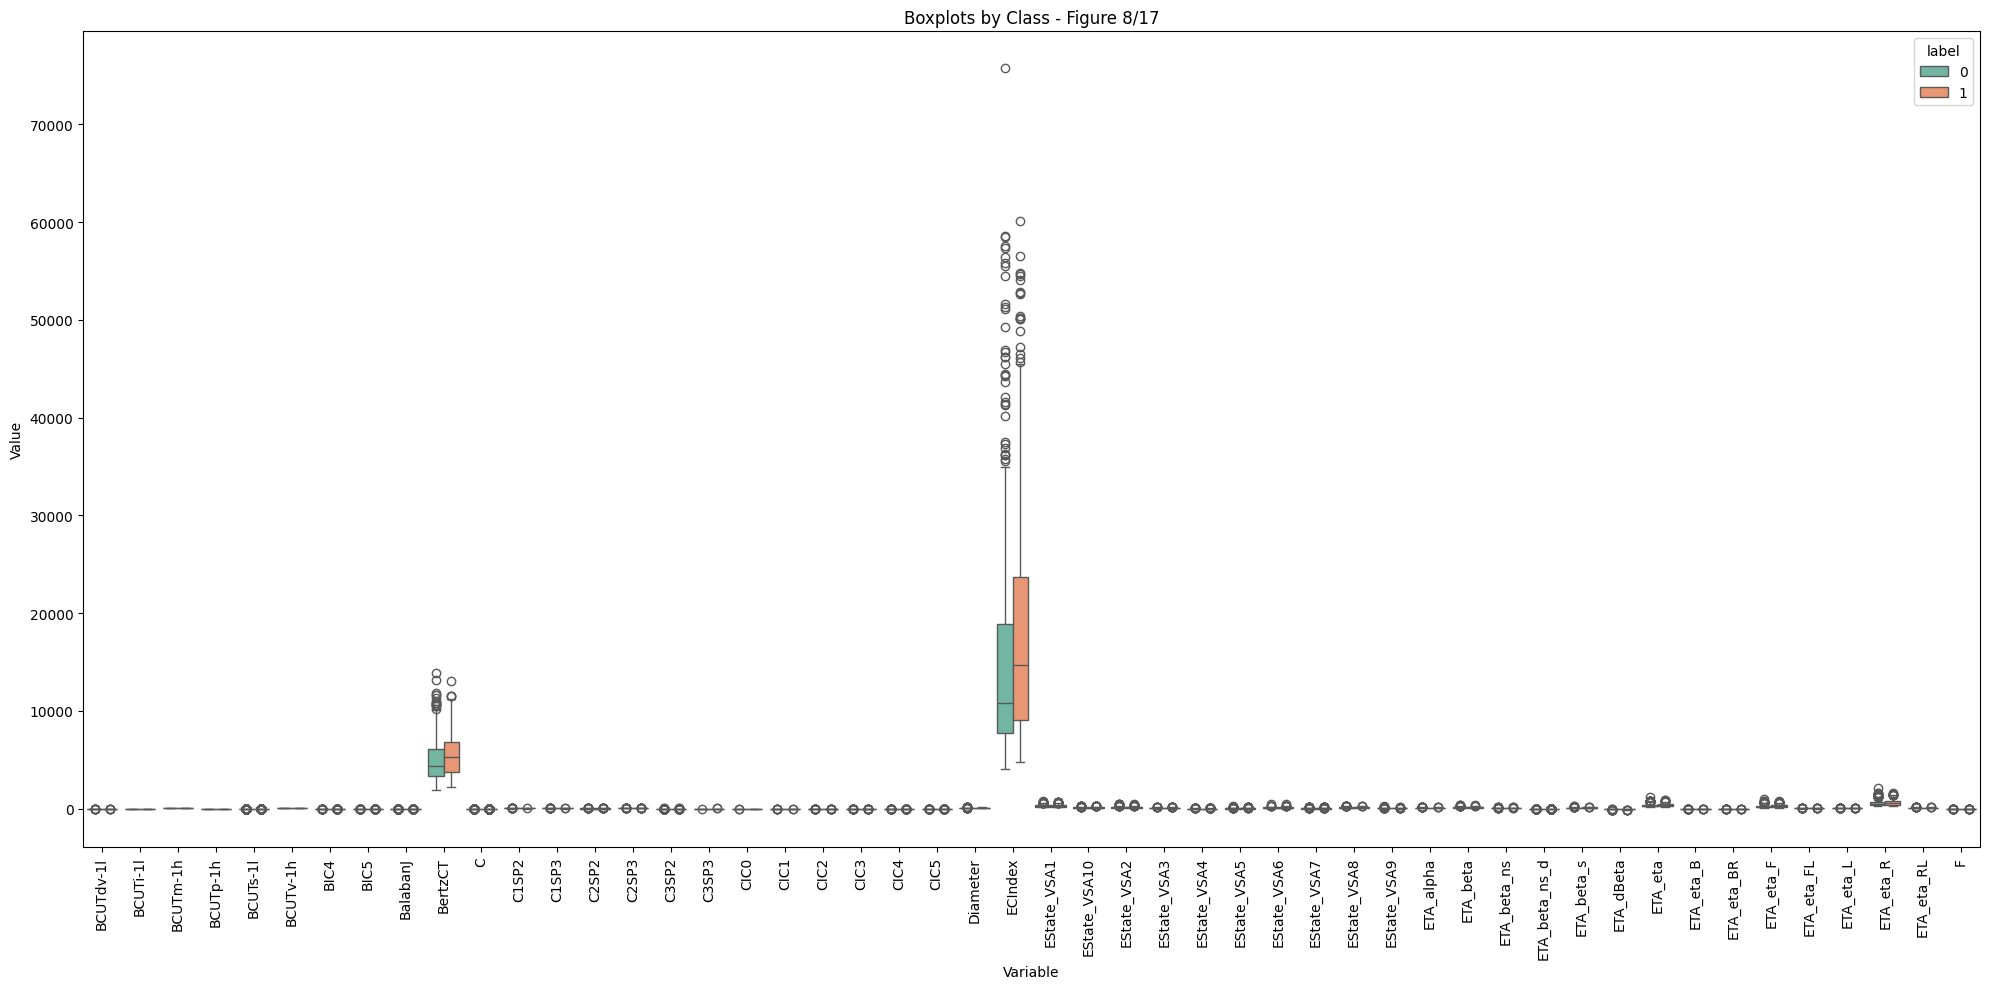

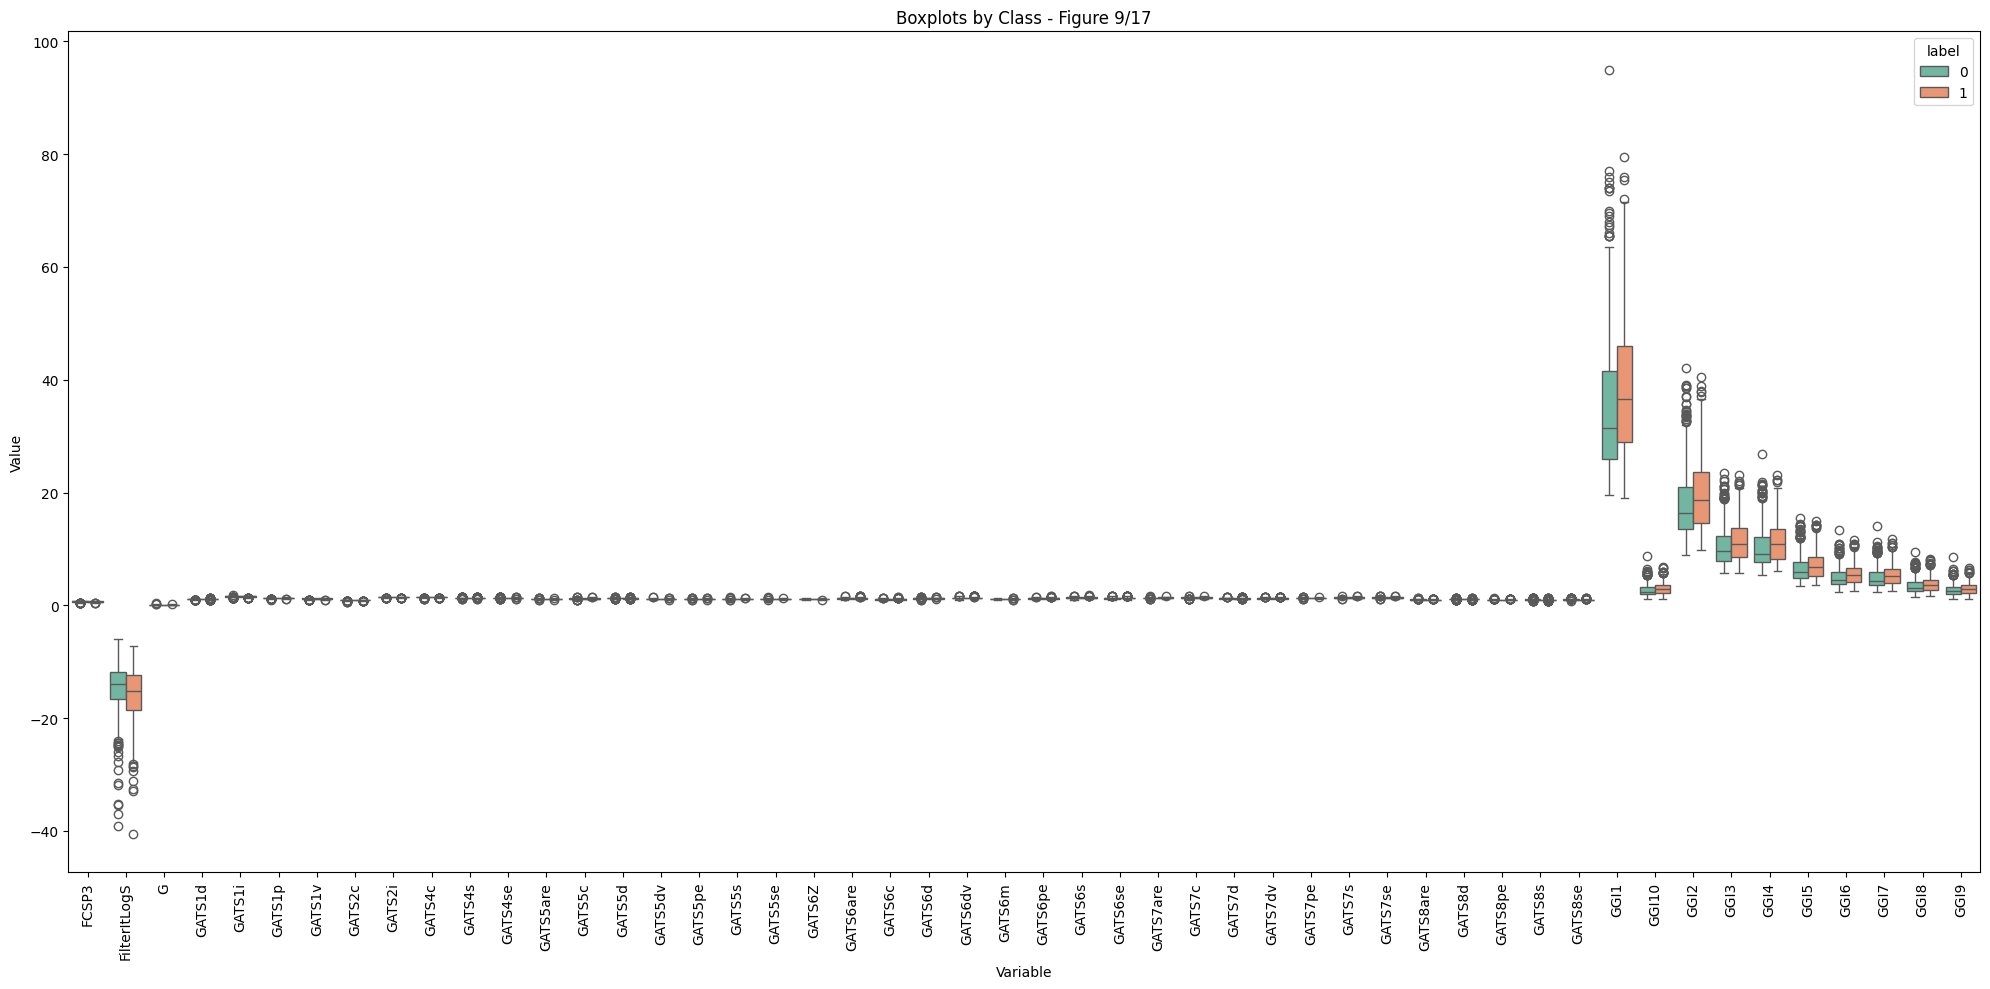

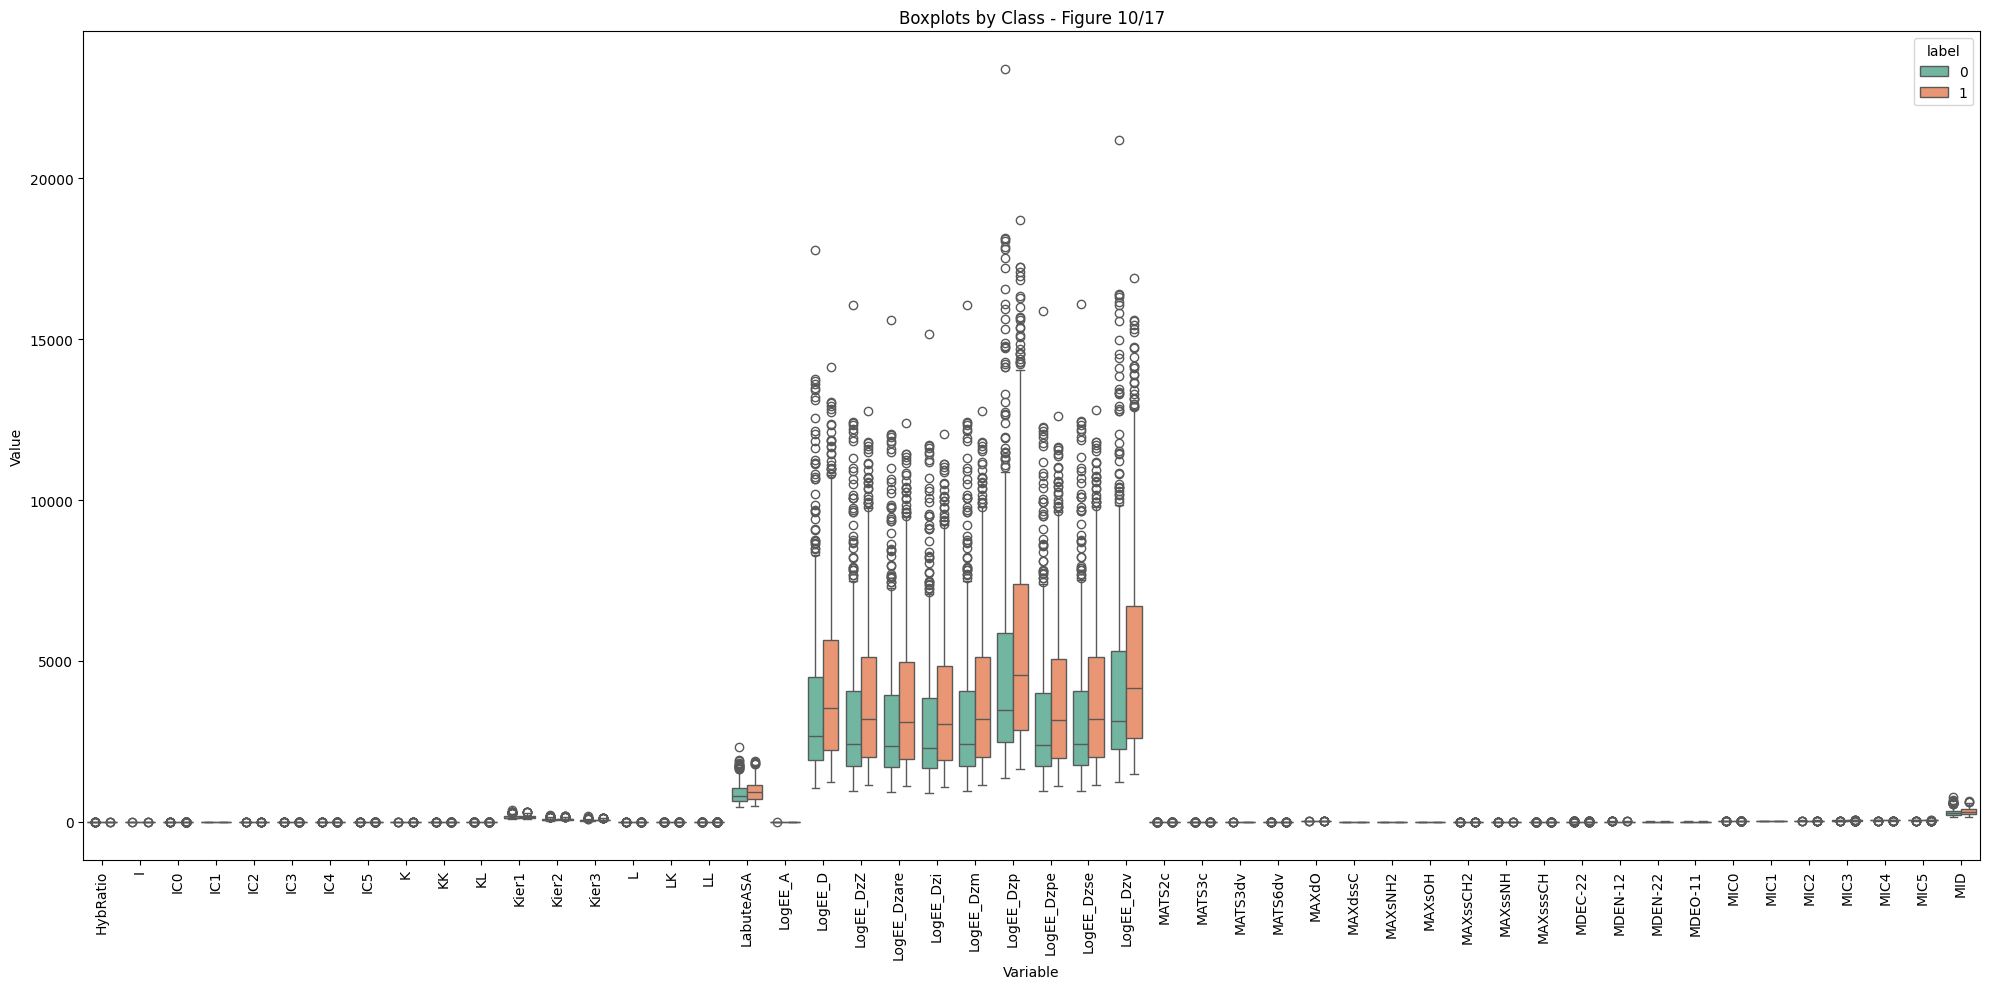

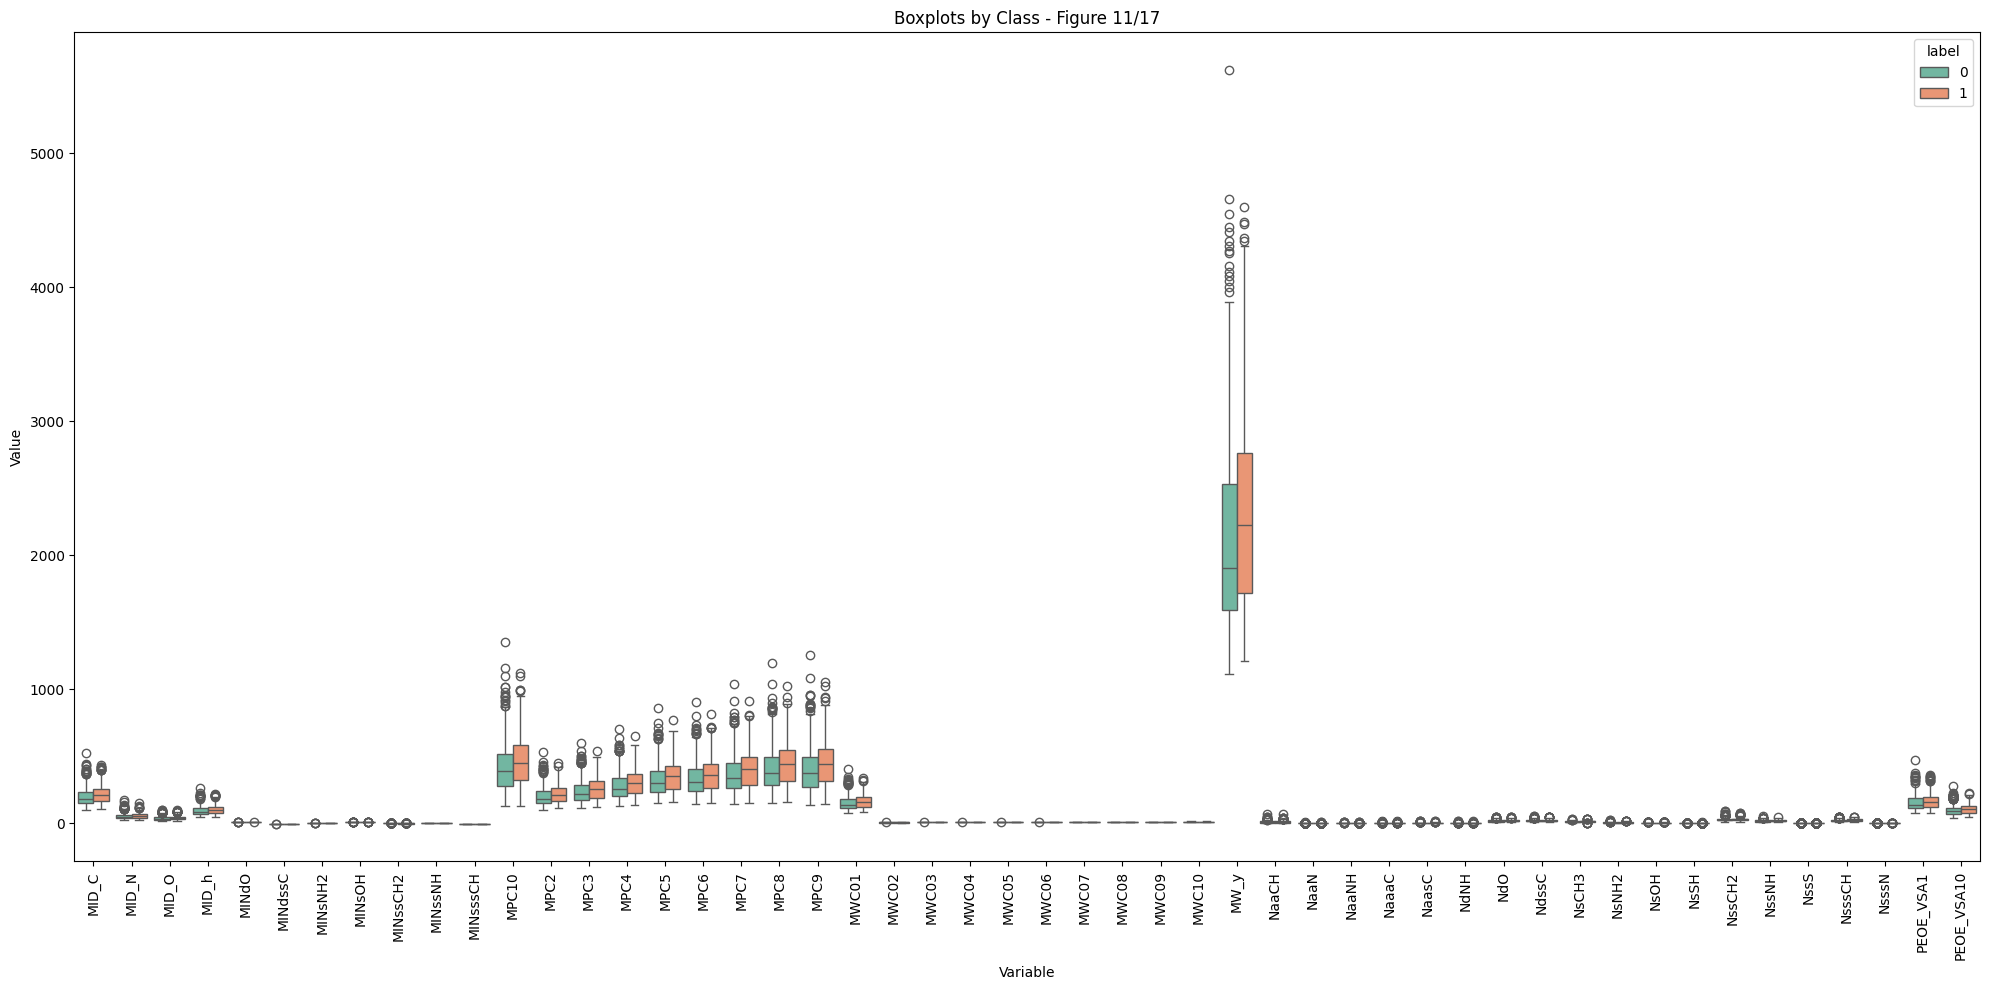

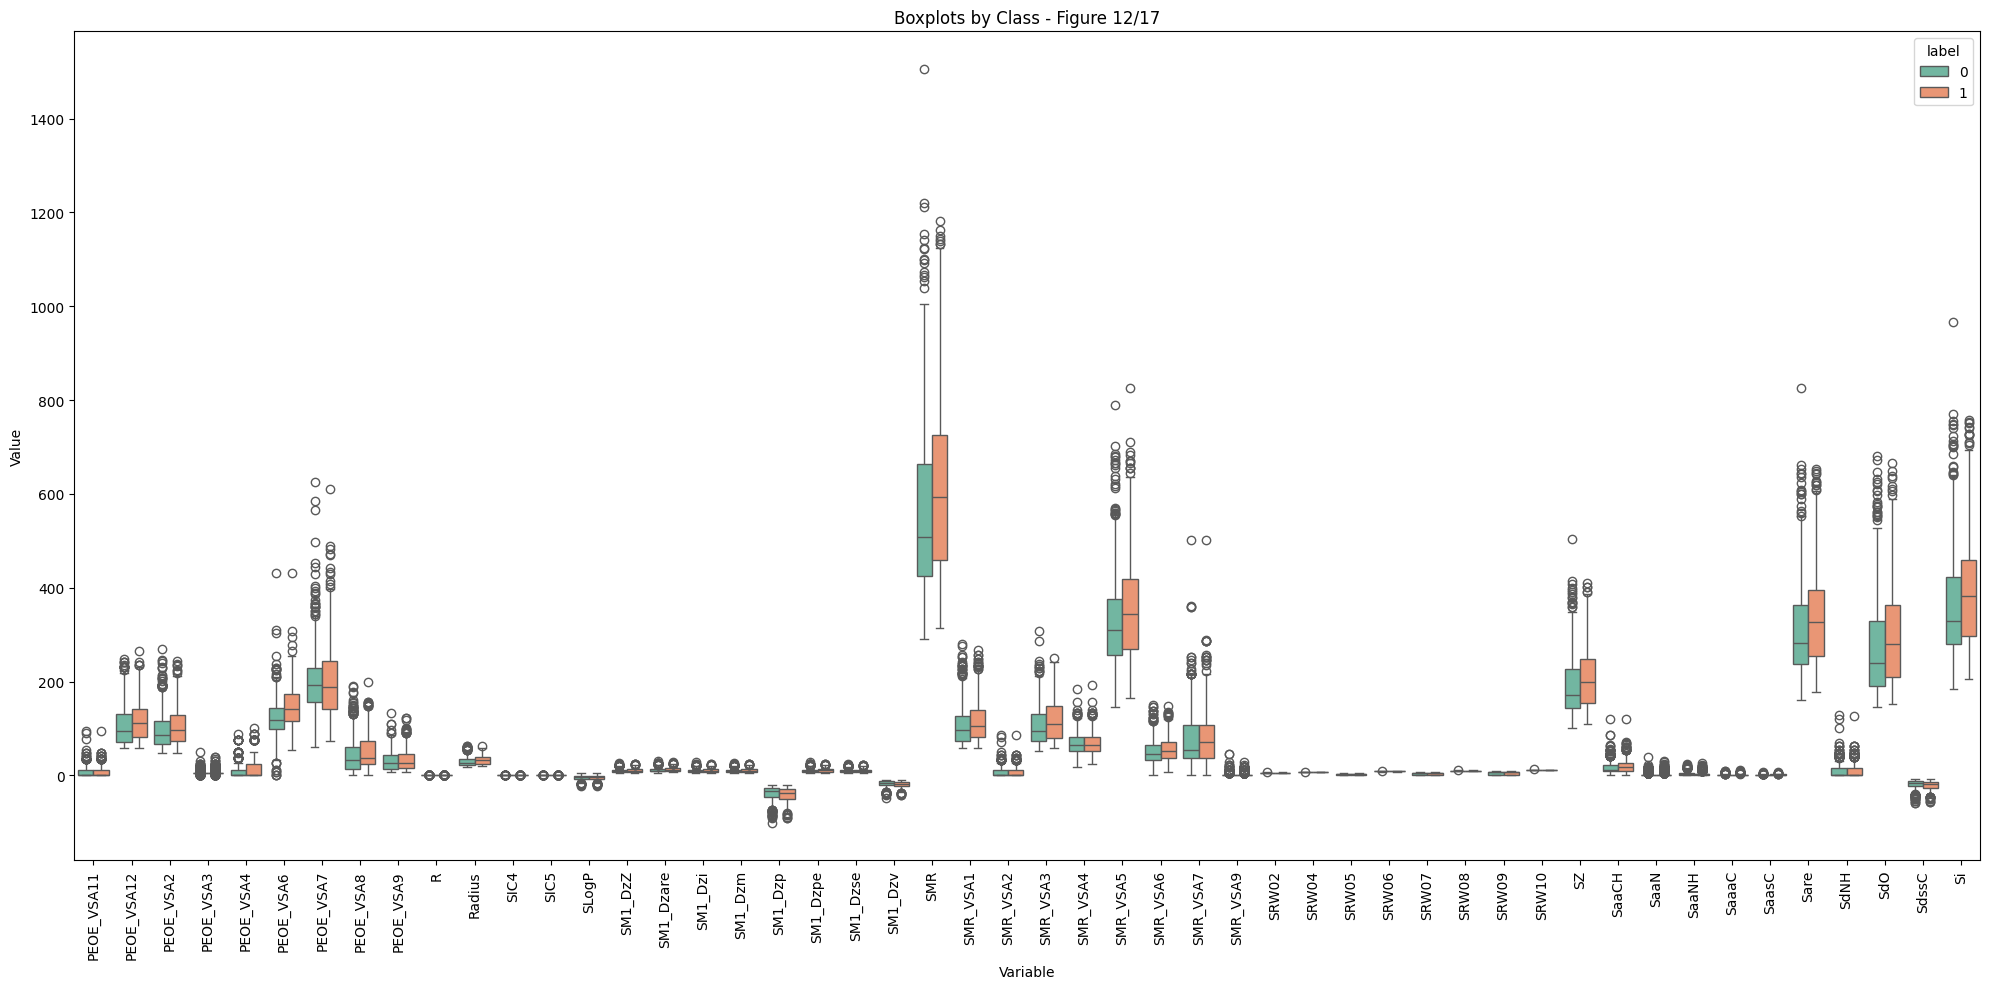

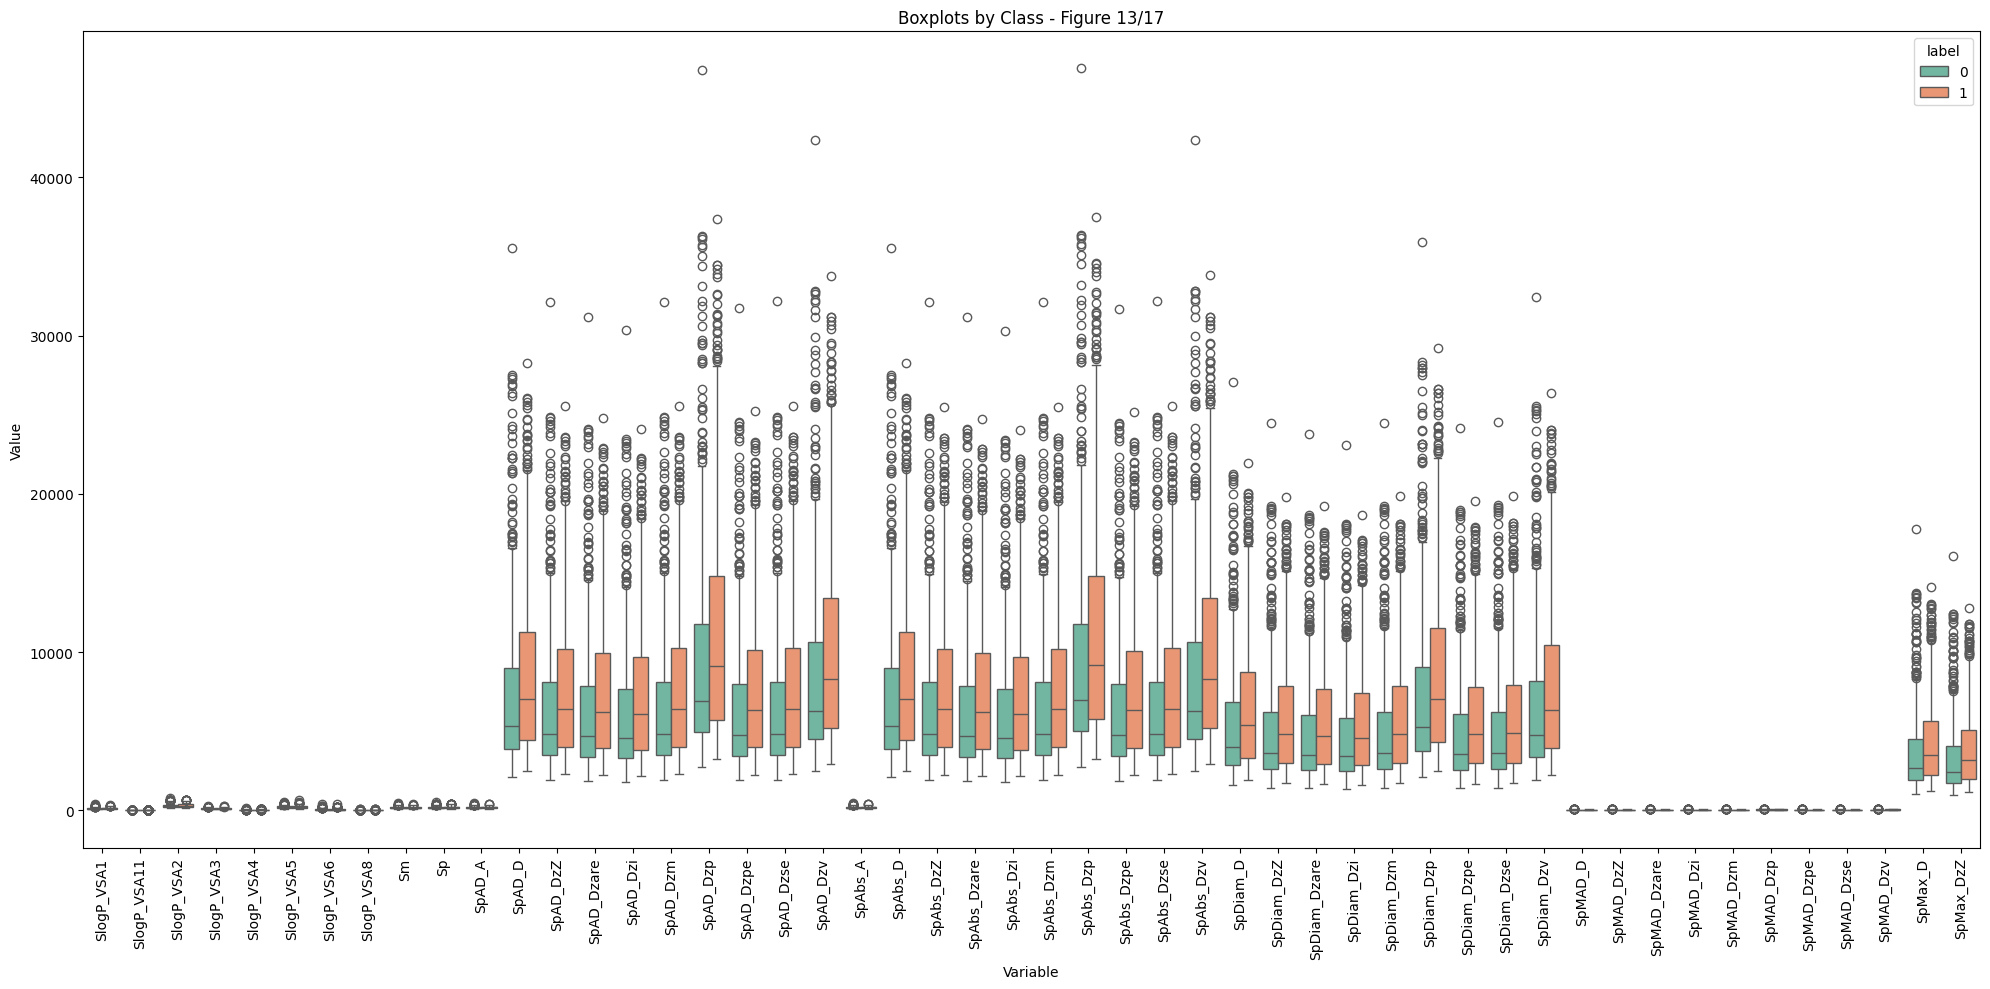

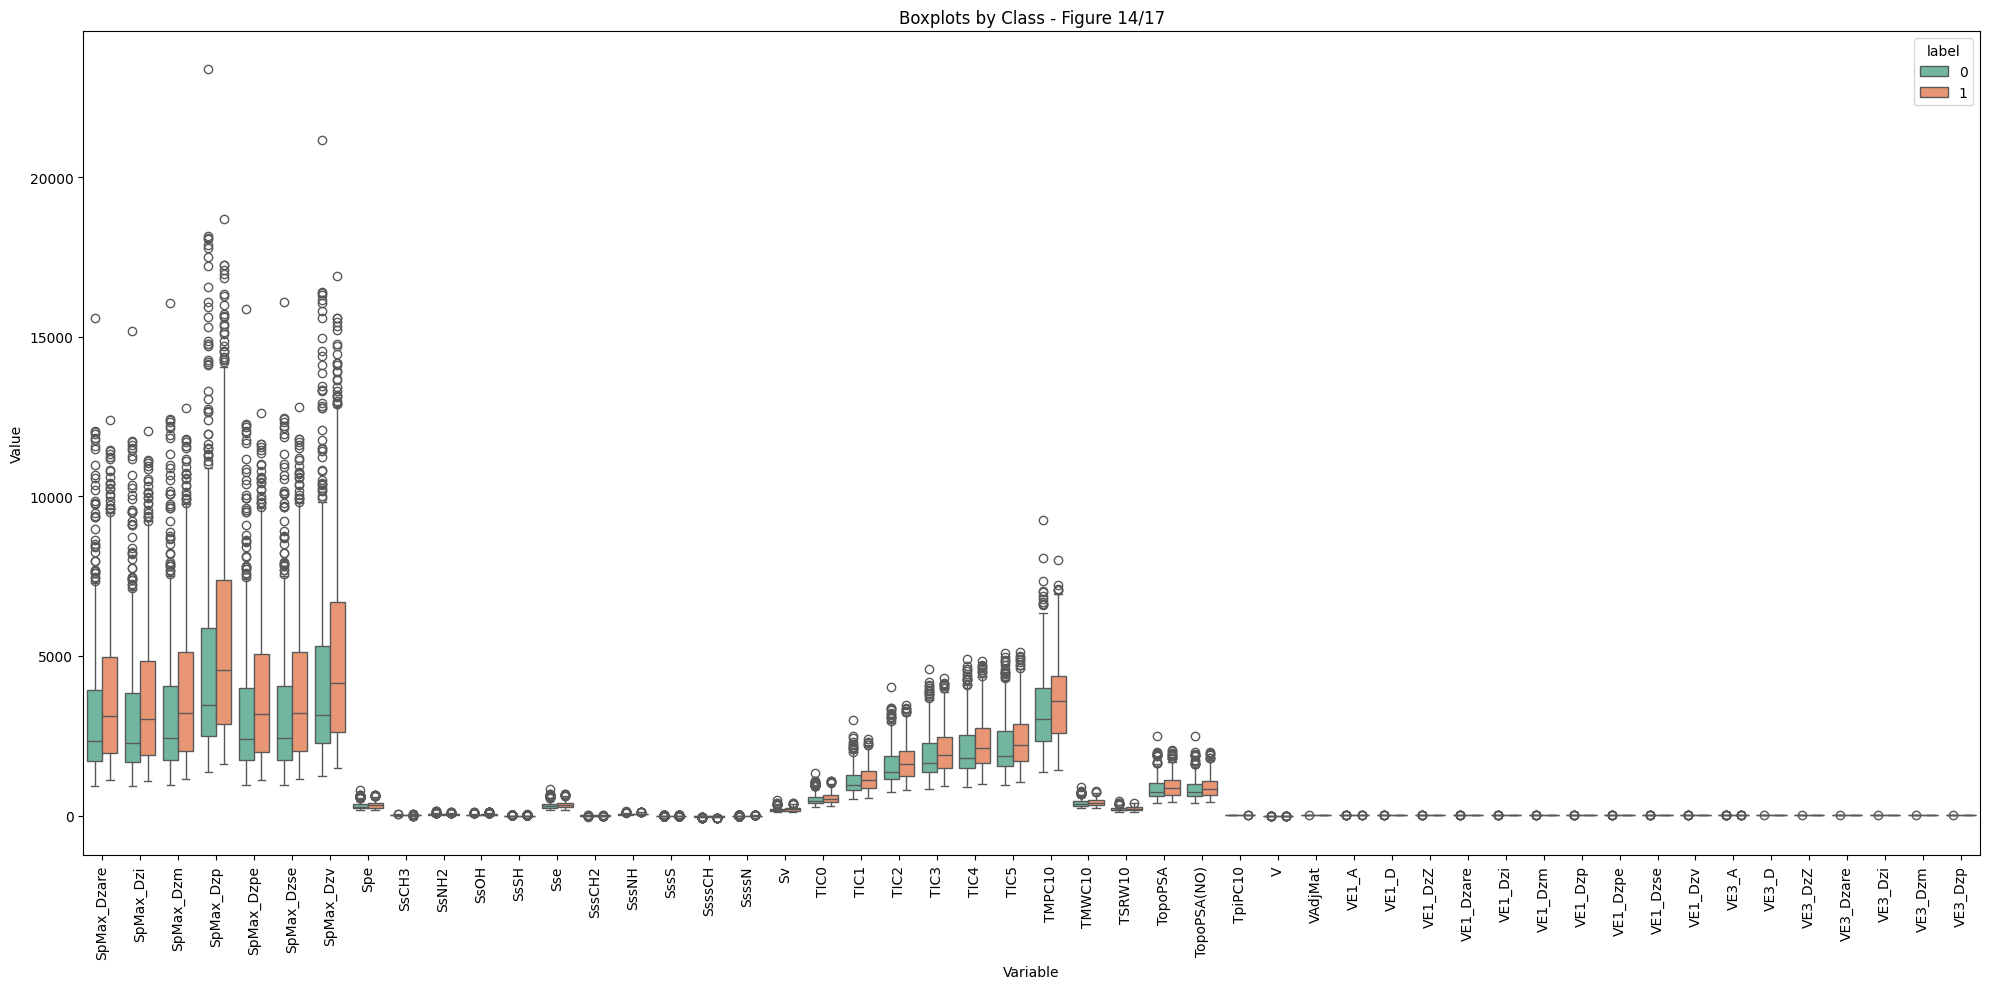

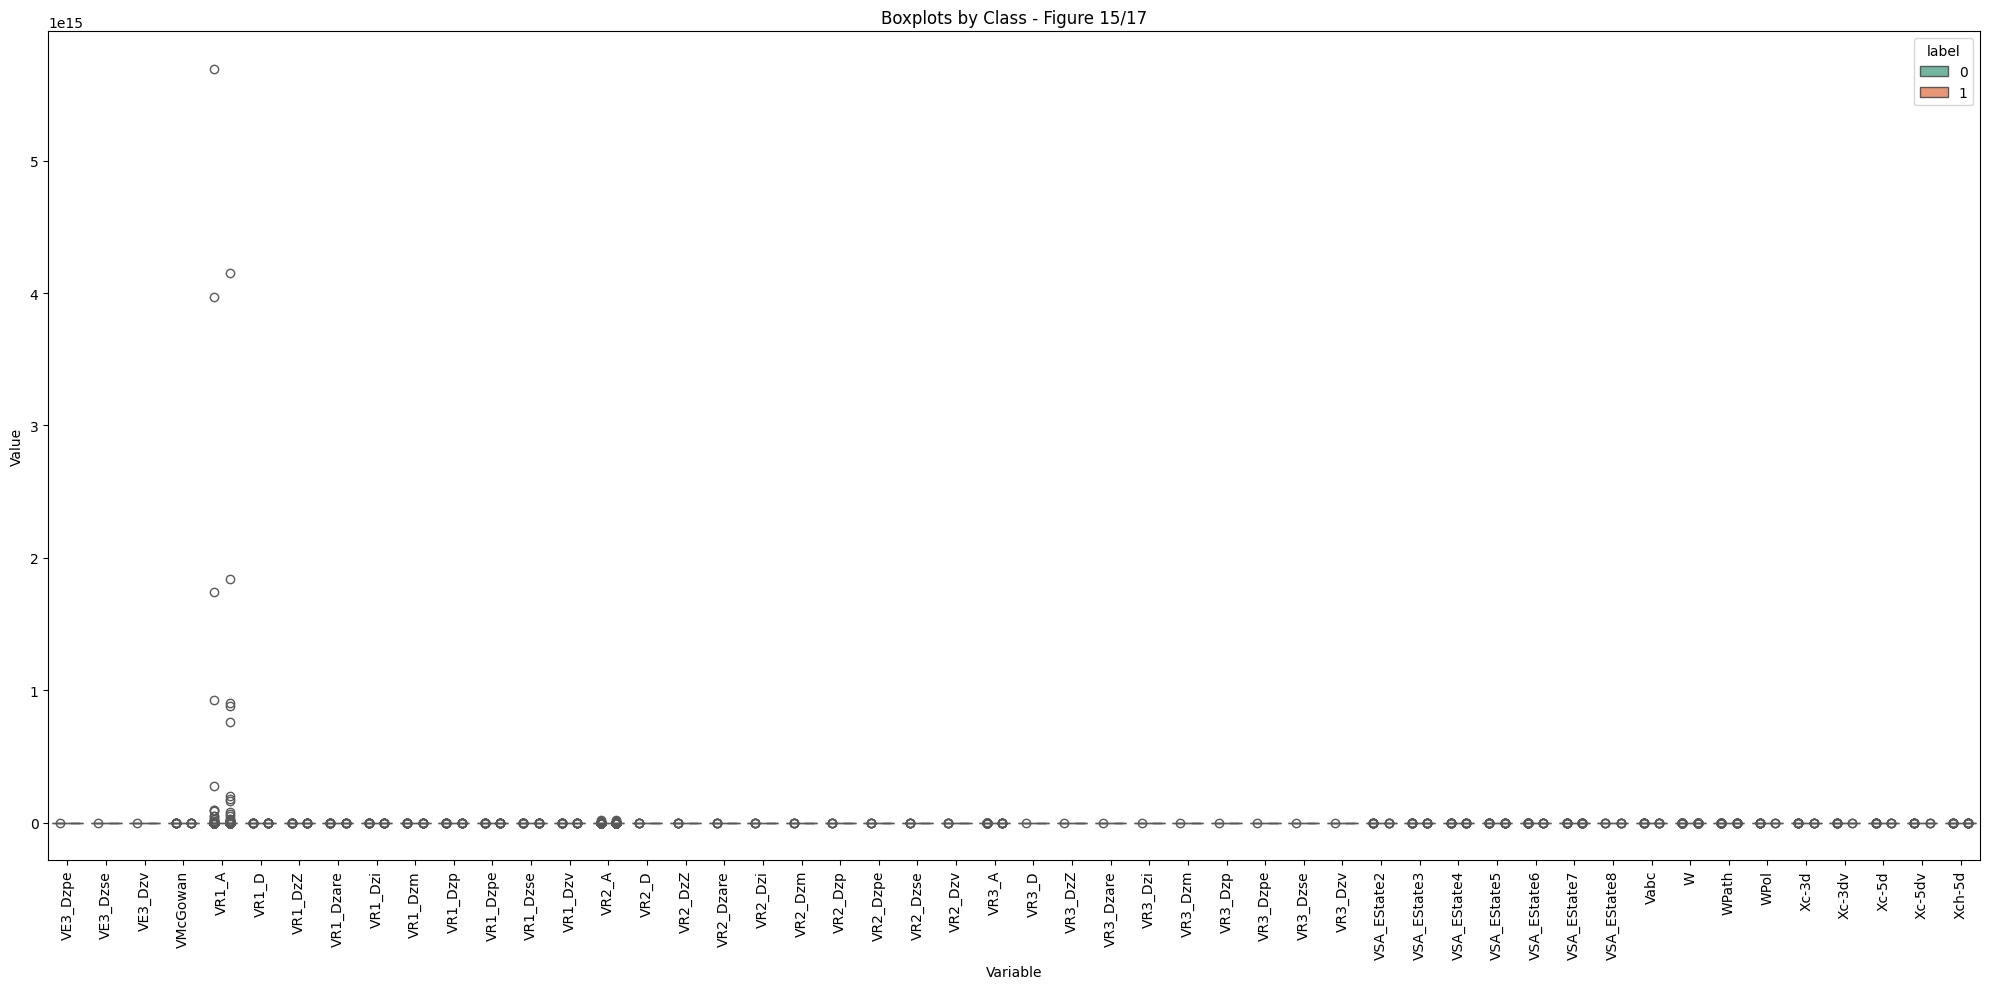

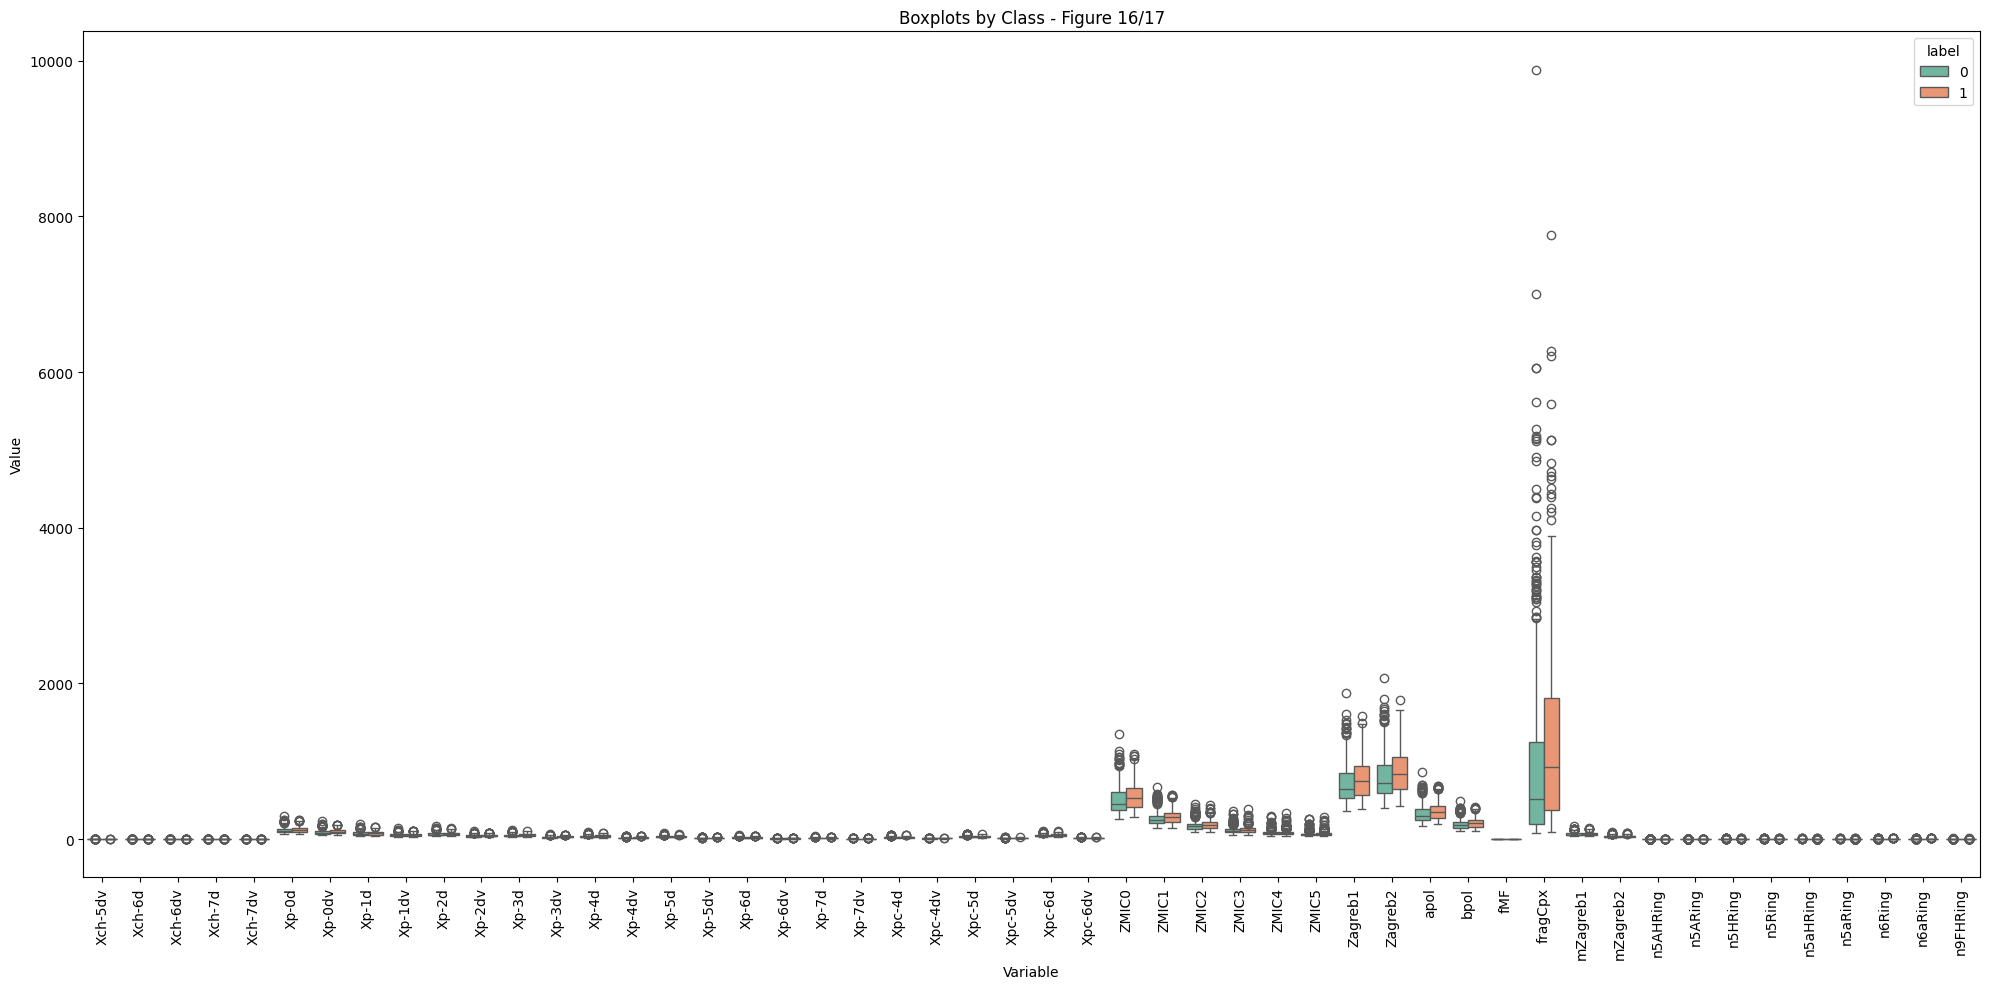

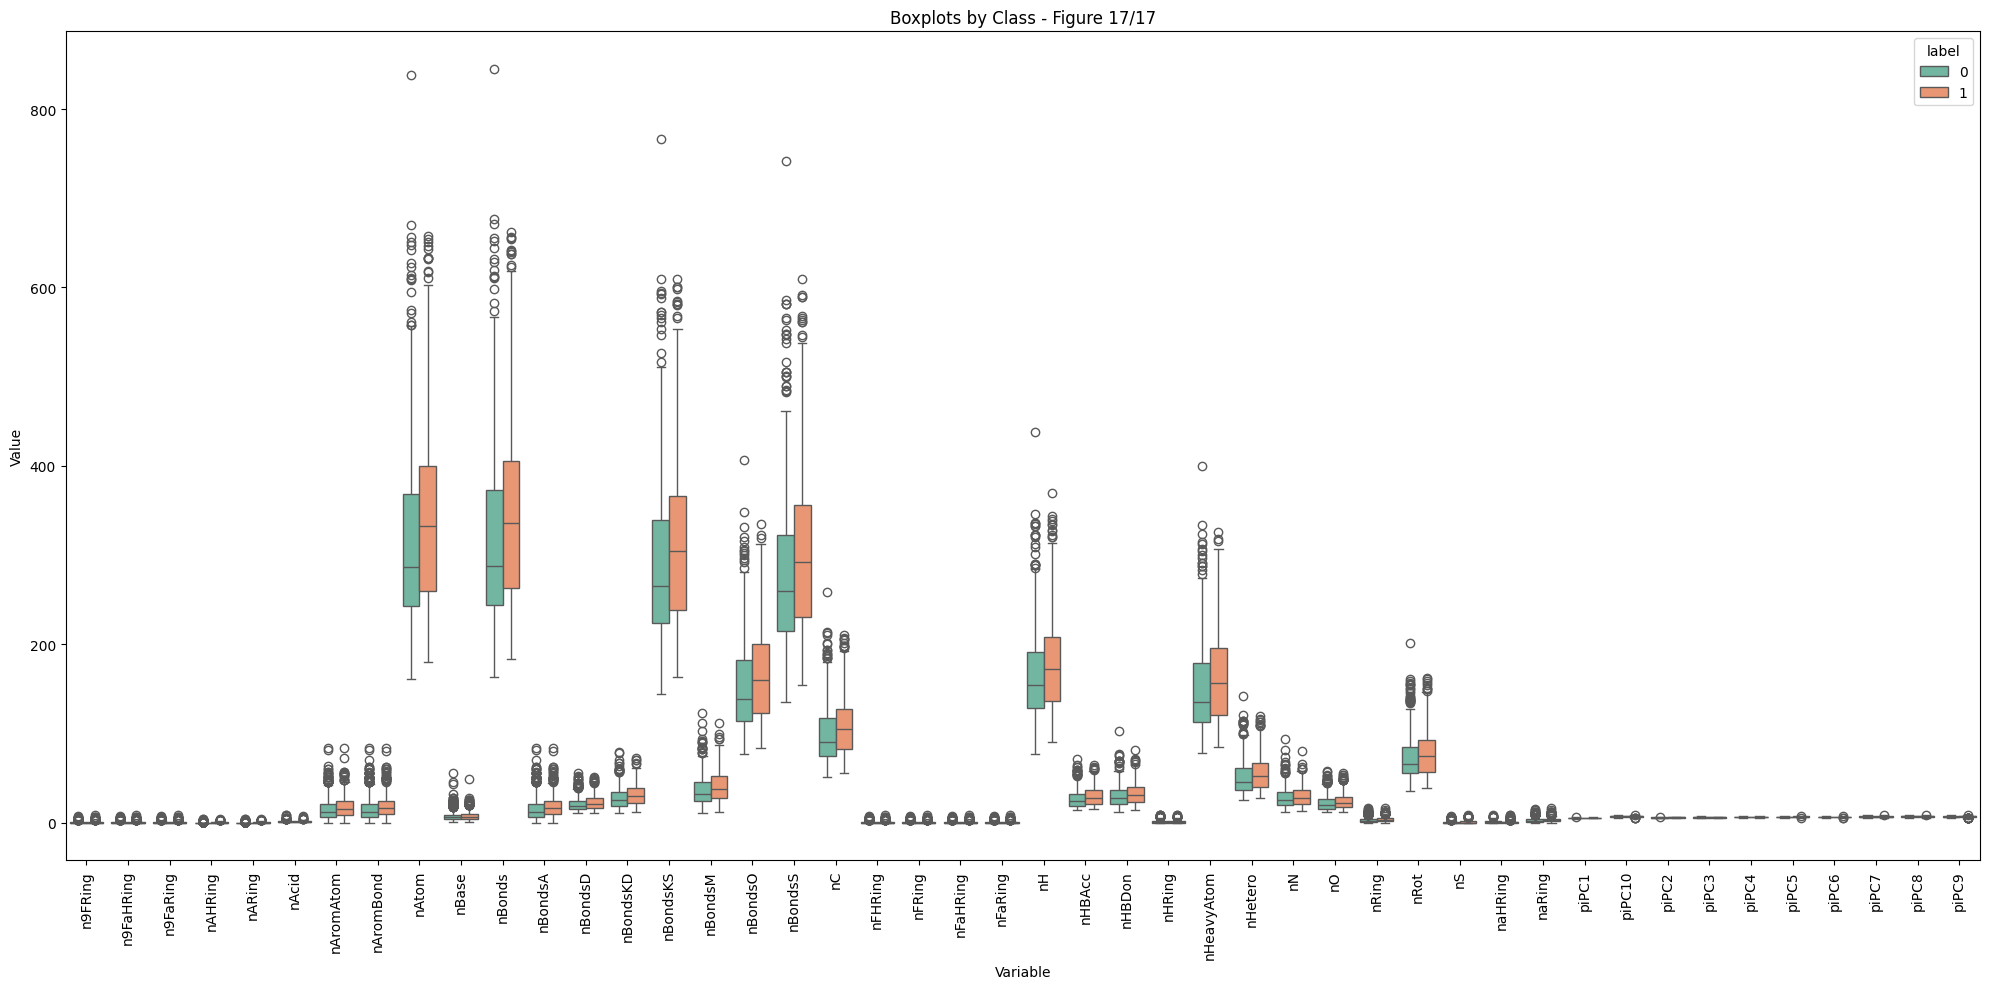

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math



def plot_boxplots_by_class(df, label_col='label', exclude_cols=None, std_threshold=0.05, vars_per_fig=50):
    if exclude_cols is None:
        exclude_cols = []
    
    # 1. Select numeric columns except excluded
    numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)
    
    # 2. Filter variables with std >= threshold
    filtered_vars = [col for col in numeric_cols if df[col].std() >= std_threshold]
    
    # 3. Calculate number of figures needed
    num_figs = math.ceil(len(filtered_vars) / vars_per_fig)
    
    # 4. Plot
    for fig_idx in range(num_figs):
        cols_to_plot = filtered_vars[fig_idx * vars_per_fig : (fig_idx + 1) * vars_per_fig]
        
        # Melt for seaborn
        df_melt = df[[label_col] + cols_to_plot].melt(id_vars=label_col, var_name='Variable', value_name='Value')
        
        plt.figure(figsize=(20, 10))
        sns.boxplot(
            data=df_melt,
            x='Variable',
            y='Value',
            hue=label_col,
            palette='Set2'
        )
        plt.xticks(rotation=90)
        plt.title(f'Boxplots by Class - Figure {fig_idx+1}/{num_figs}')
        plt.tight_layout()
        plt.show()

# Example usage:
exclude_cols = ['μM', 'label', 'SEQUENCE']  # Exclude key & target
plot_boxplots_by_class(df_filtered, label_col='label', exclude_cols=exclude_cols, std_threshold=0.05, vars_per_fig=50)

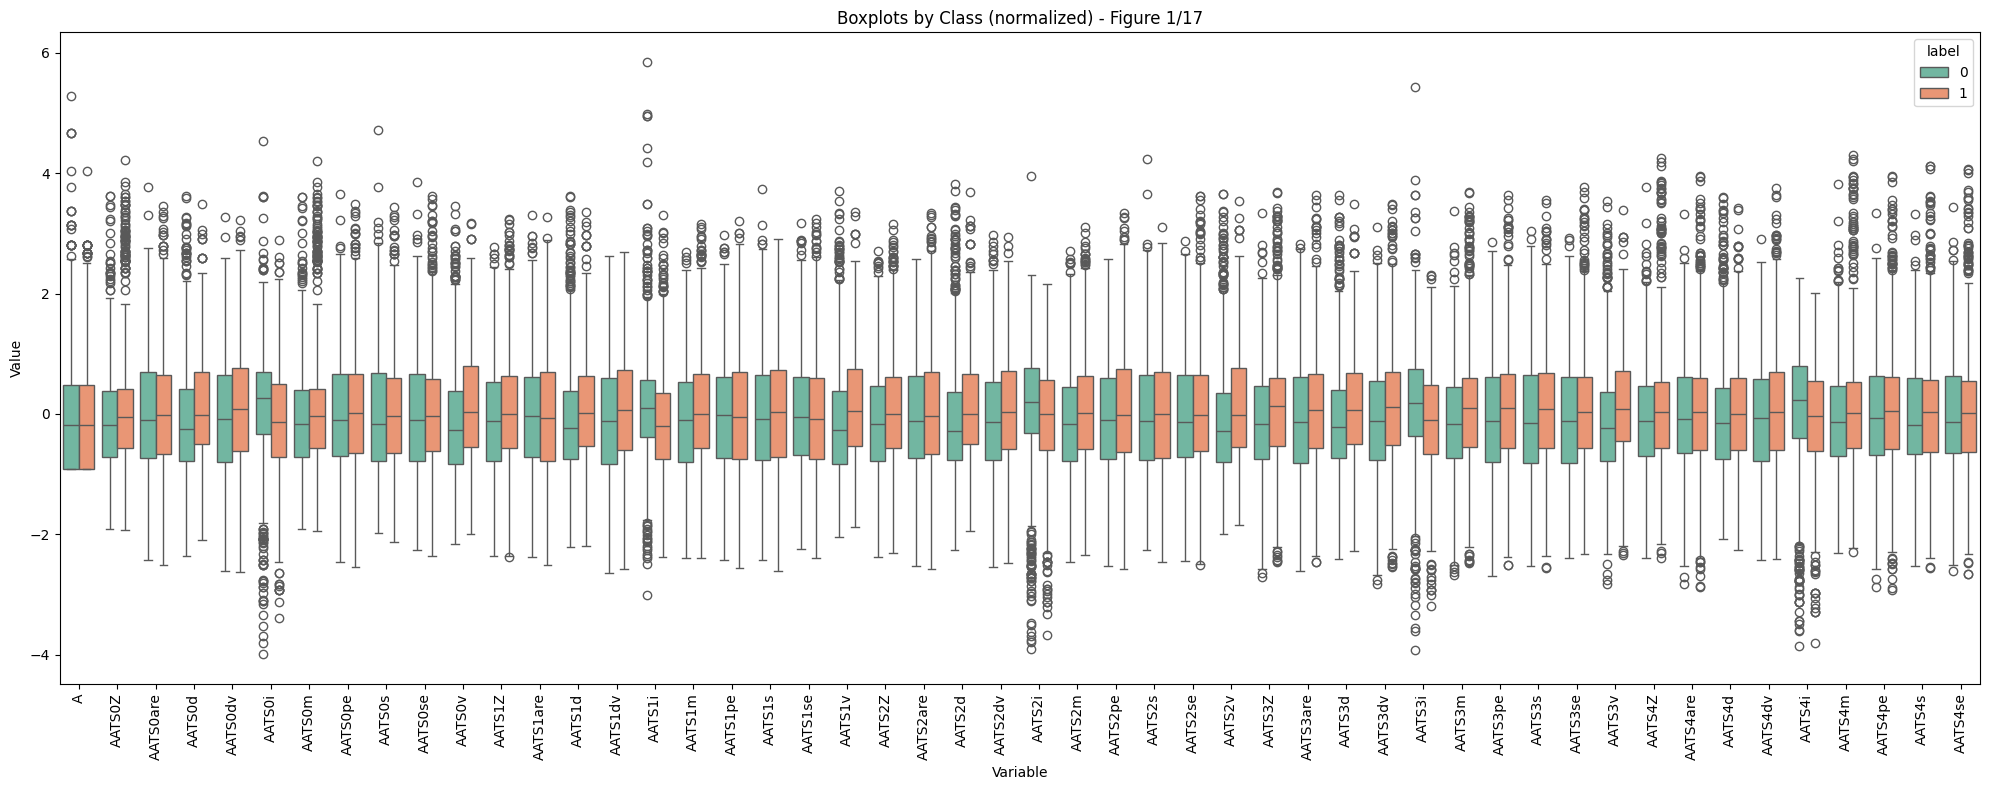

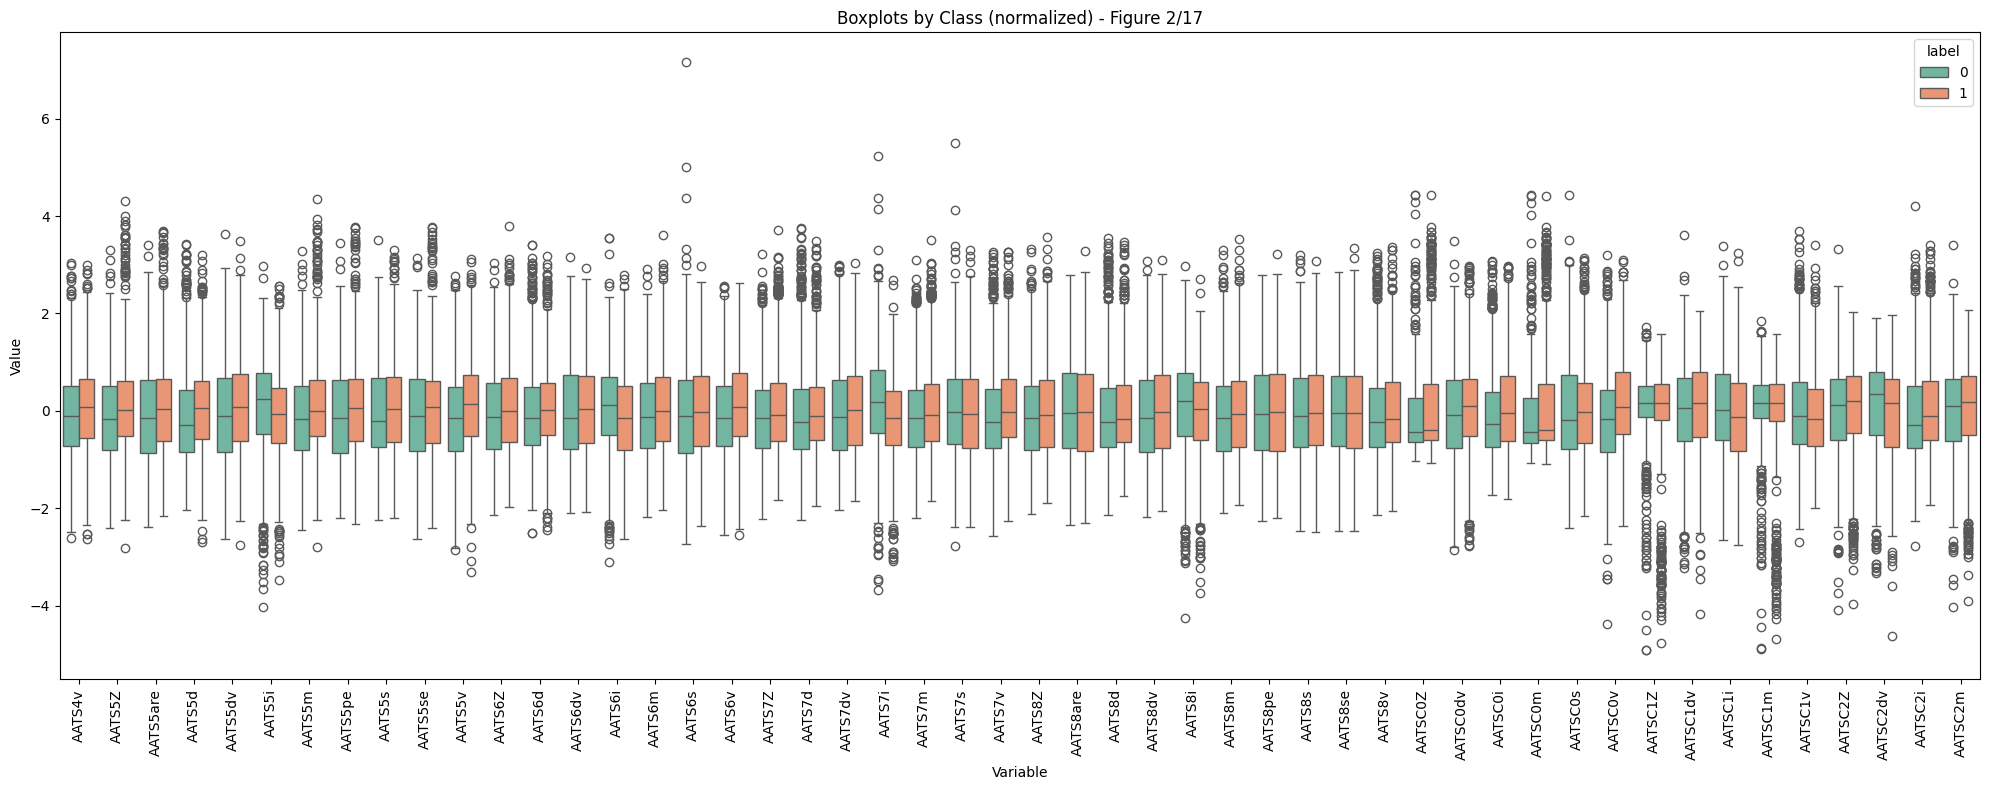

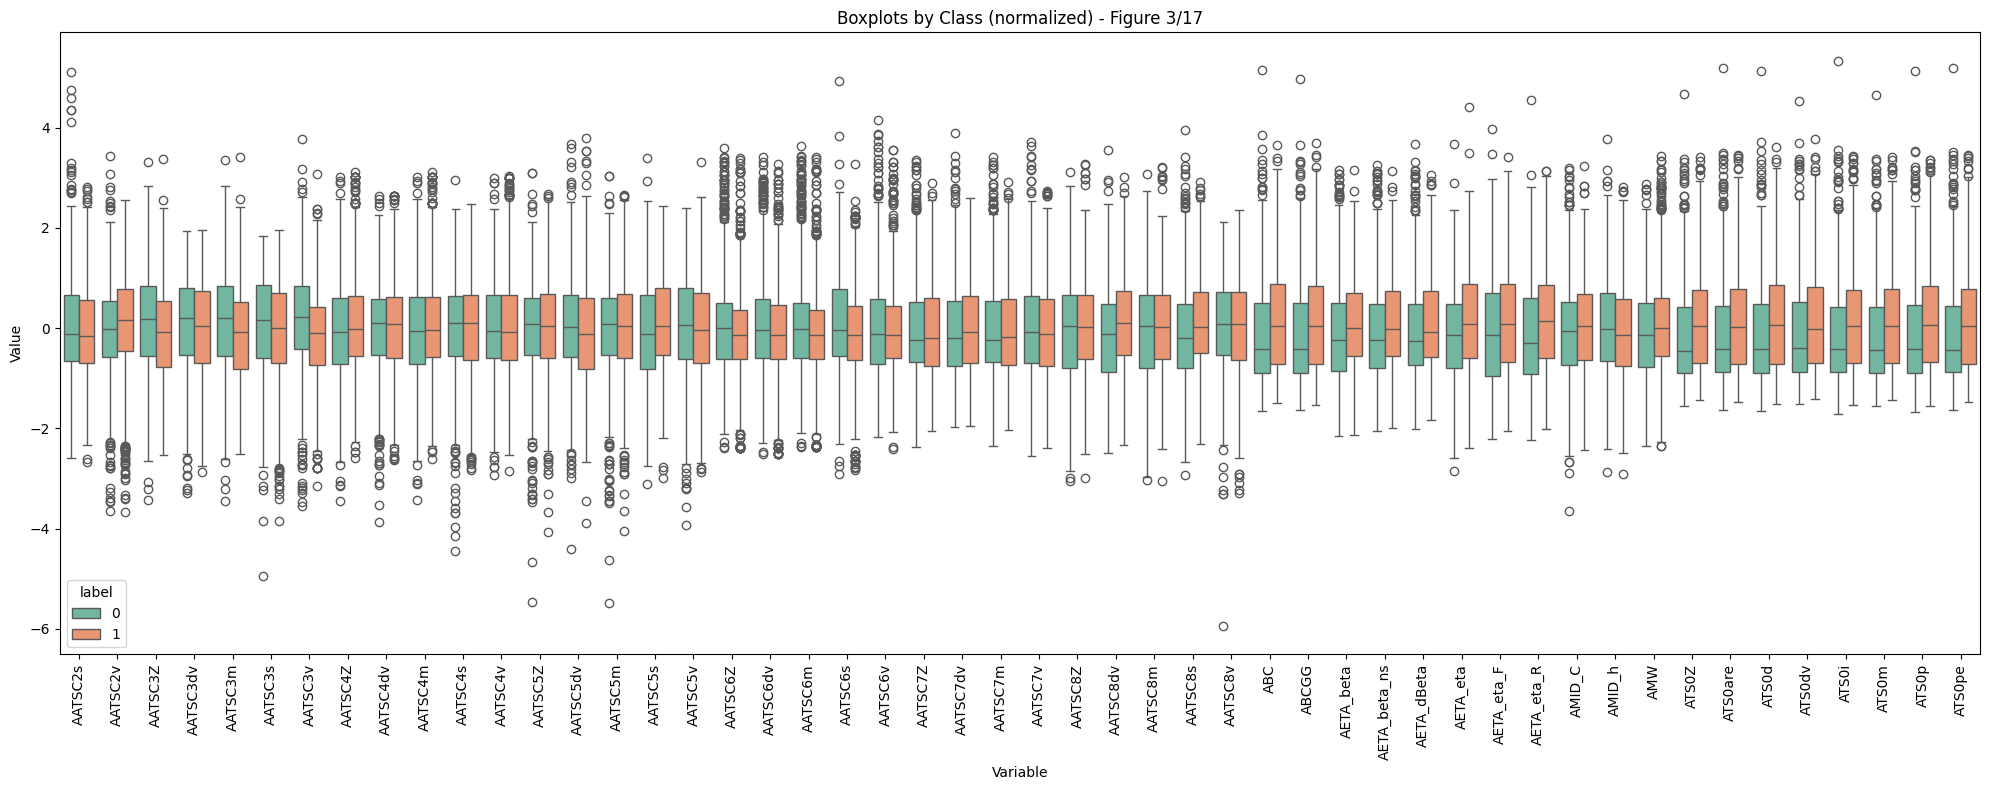

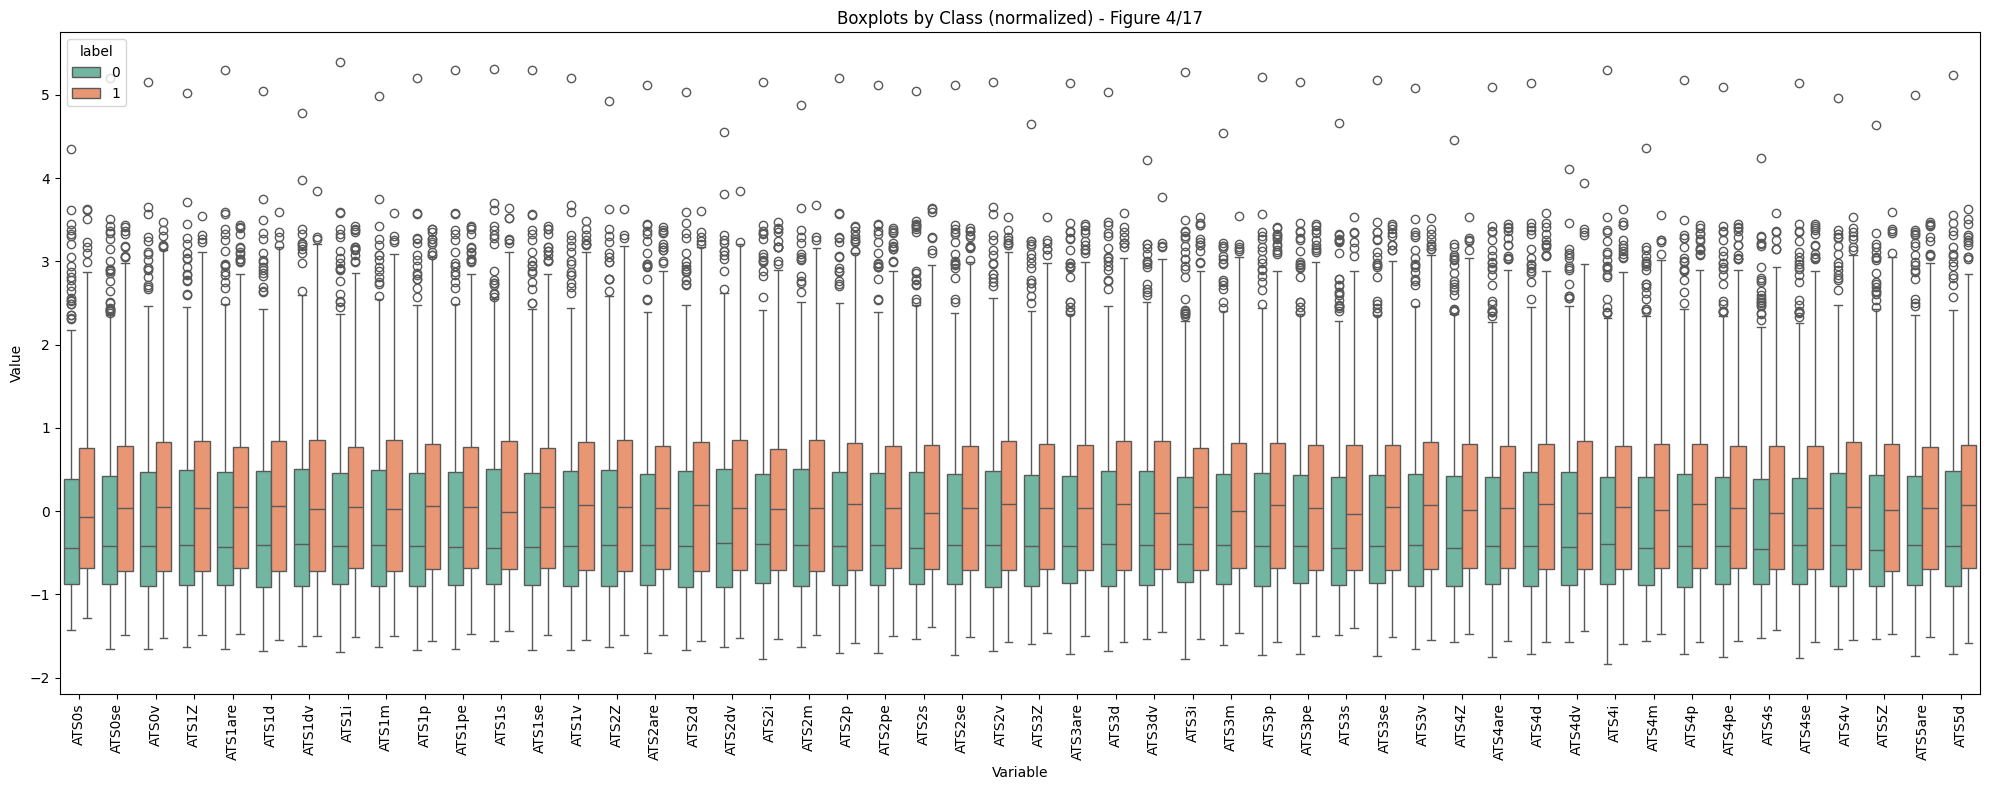

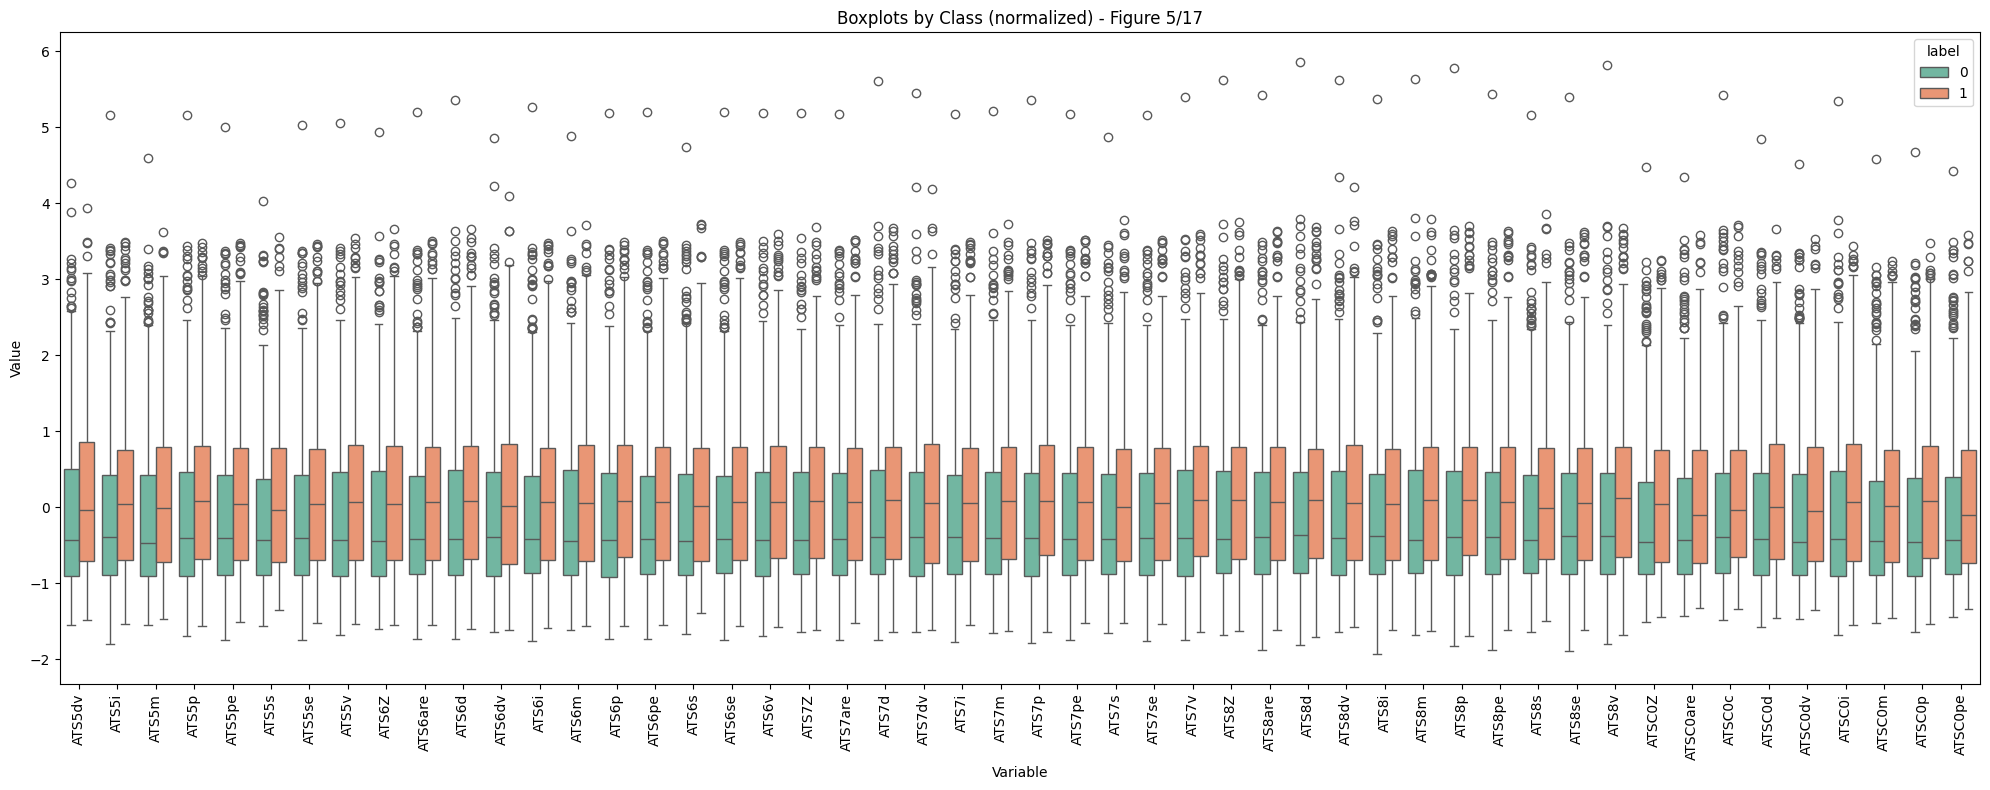

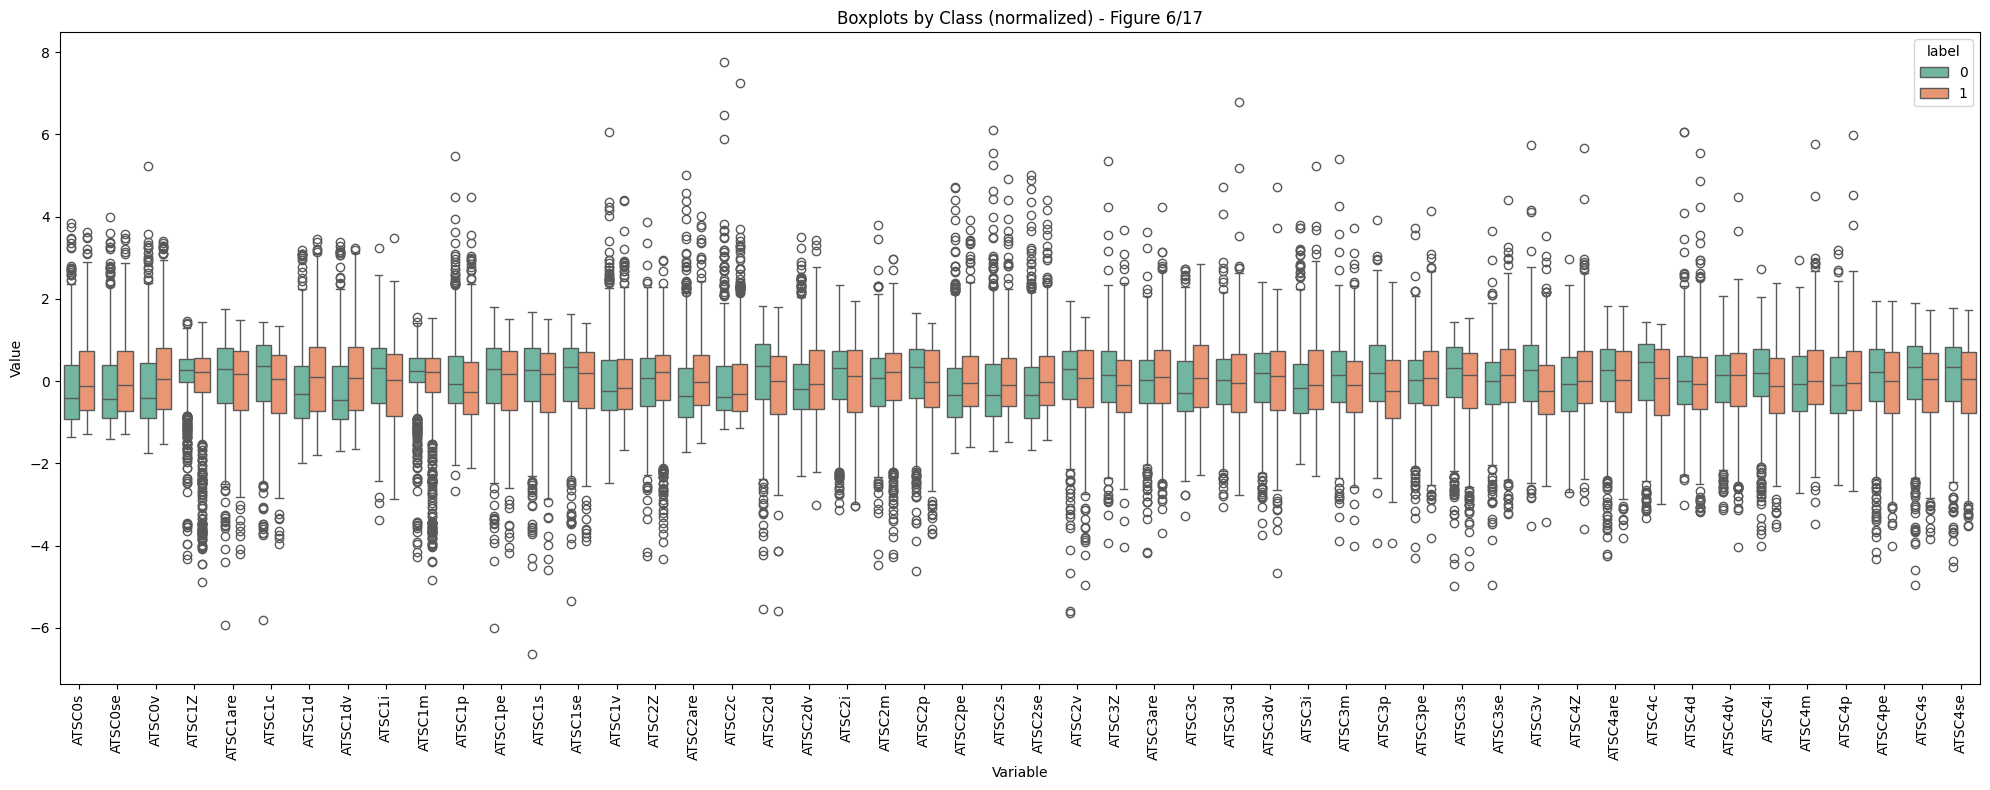

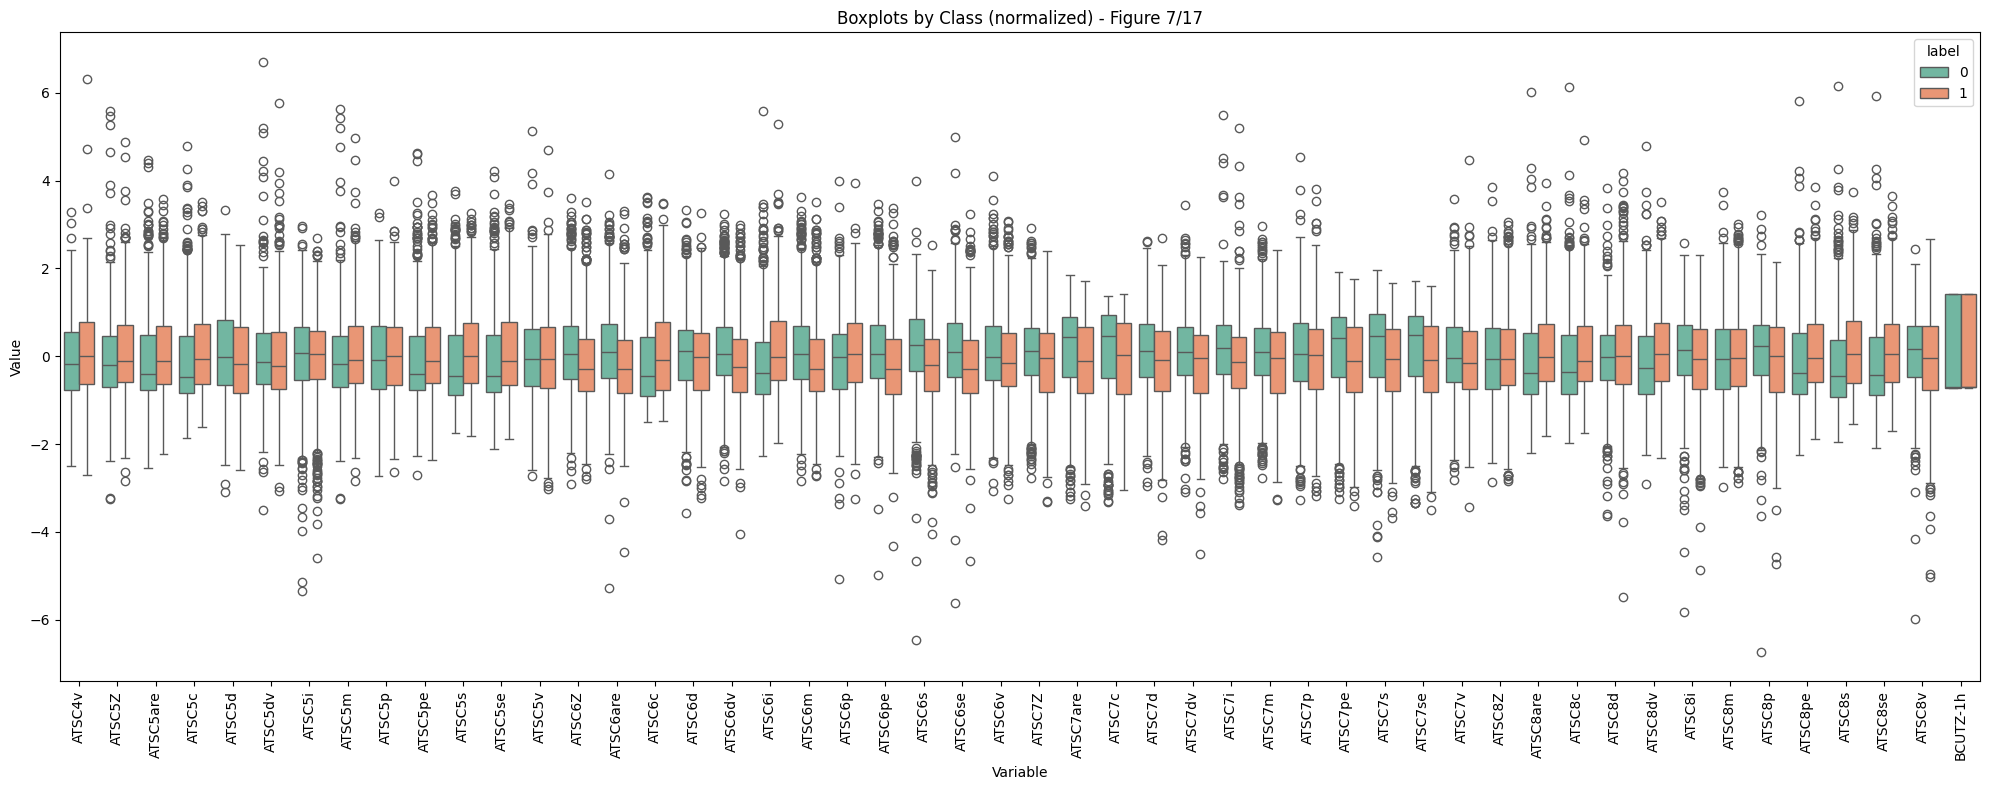

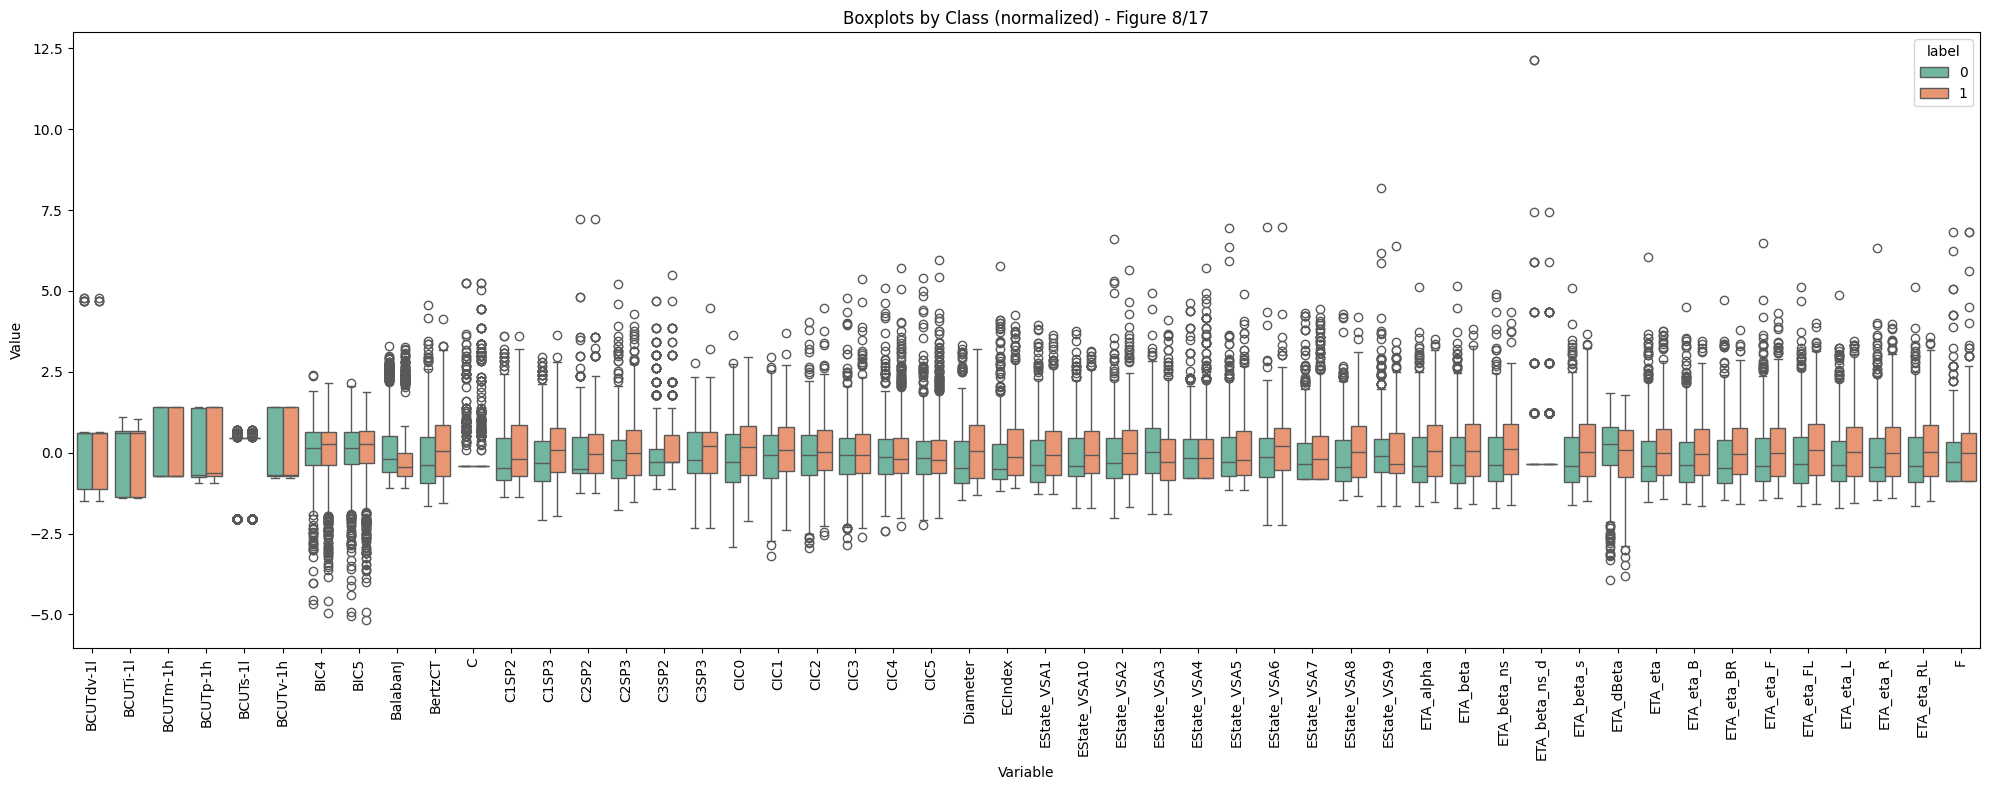

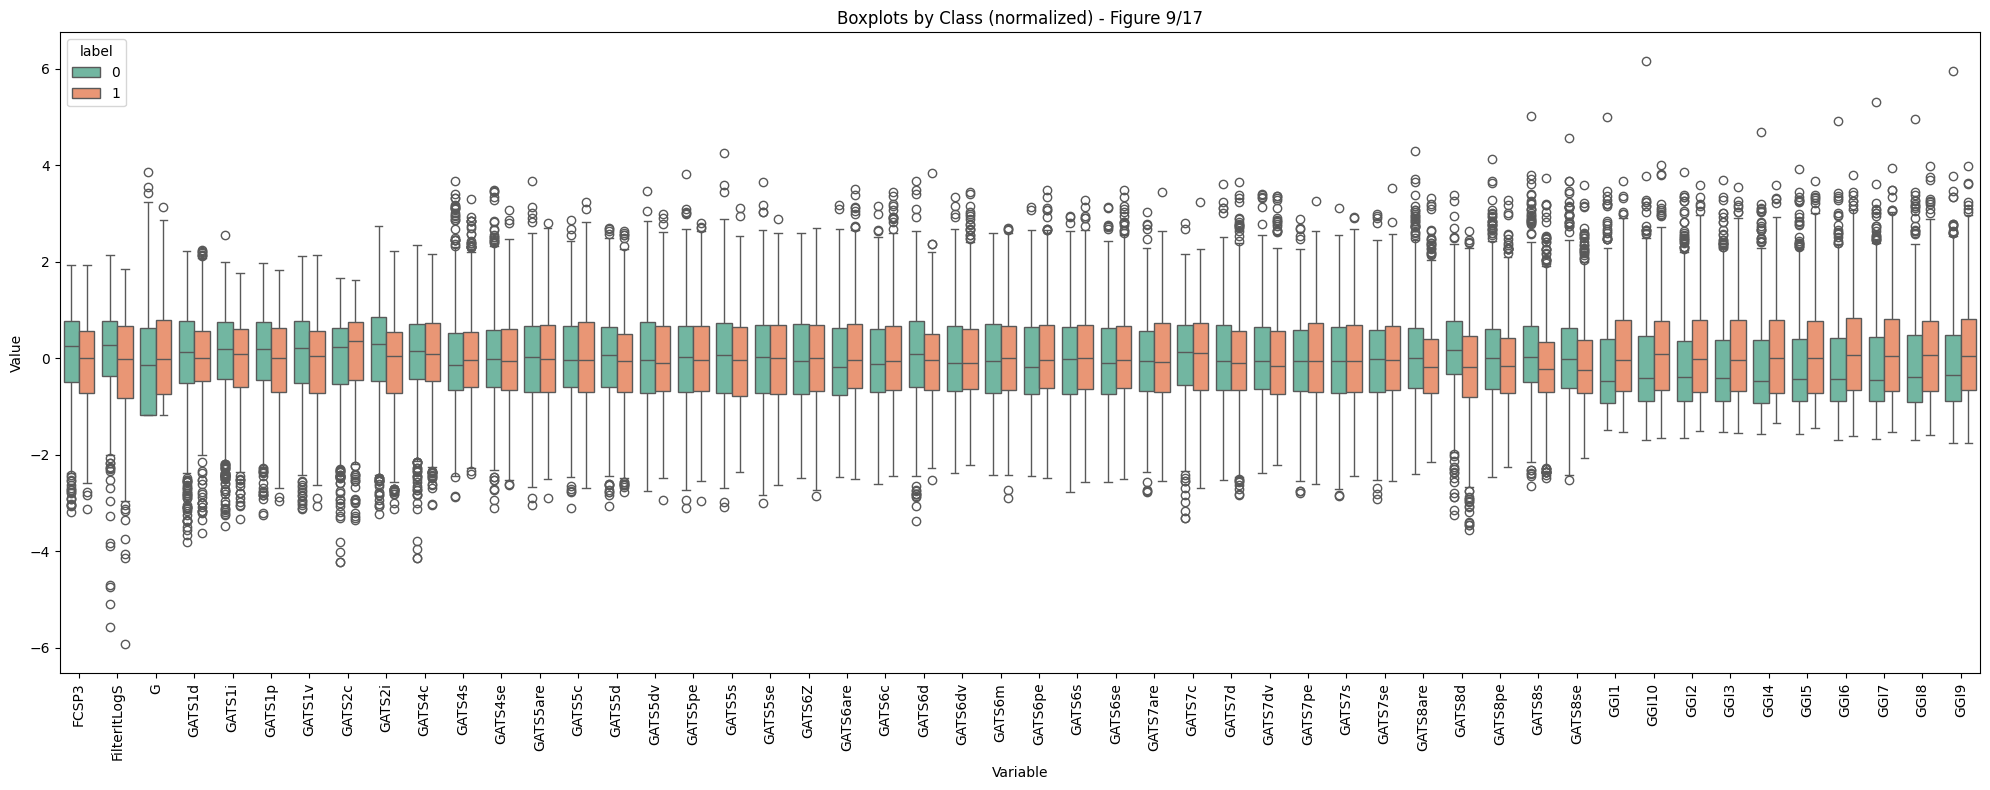

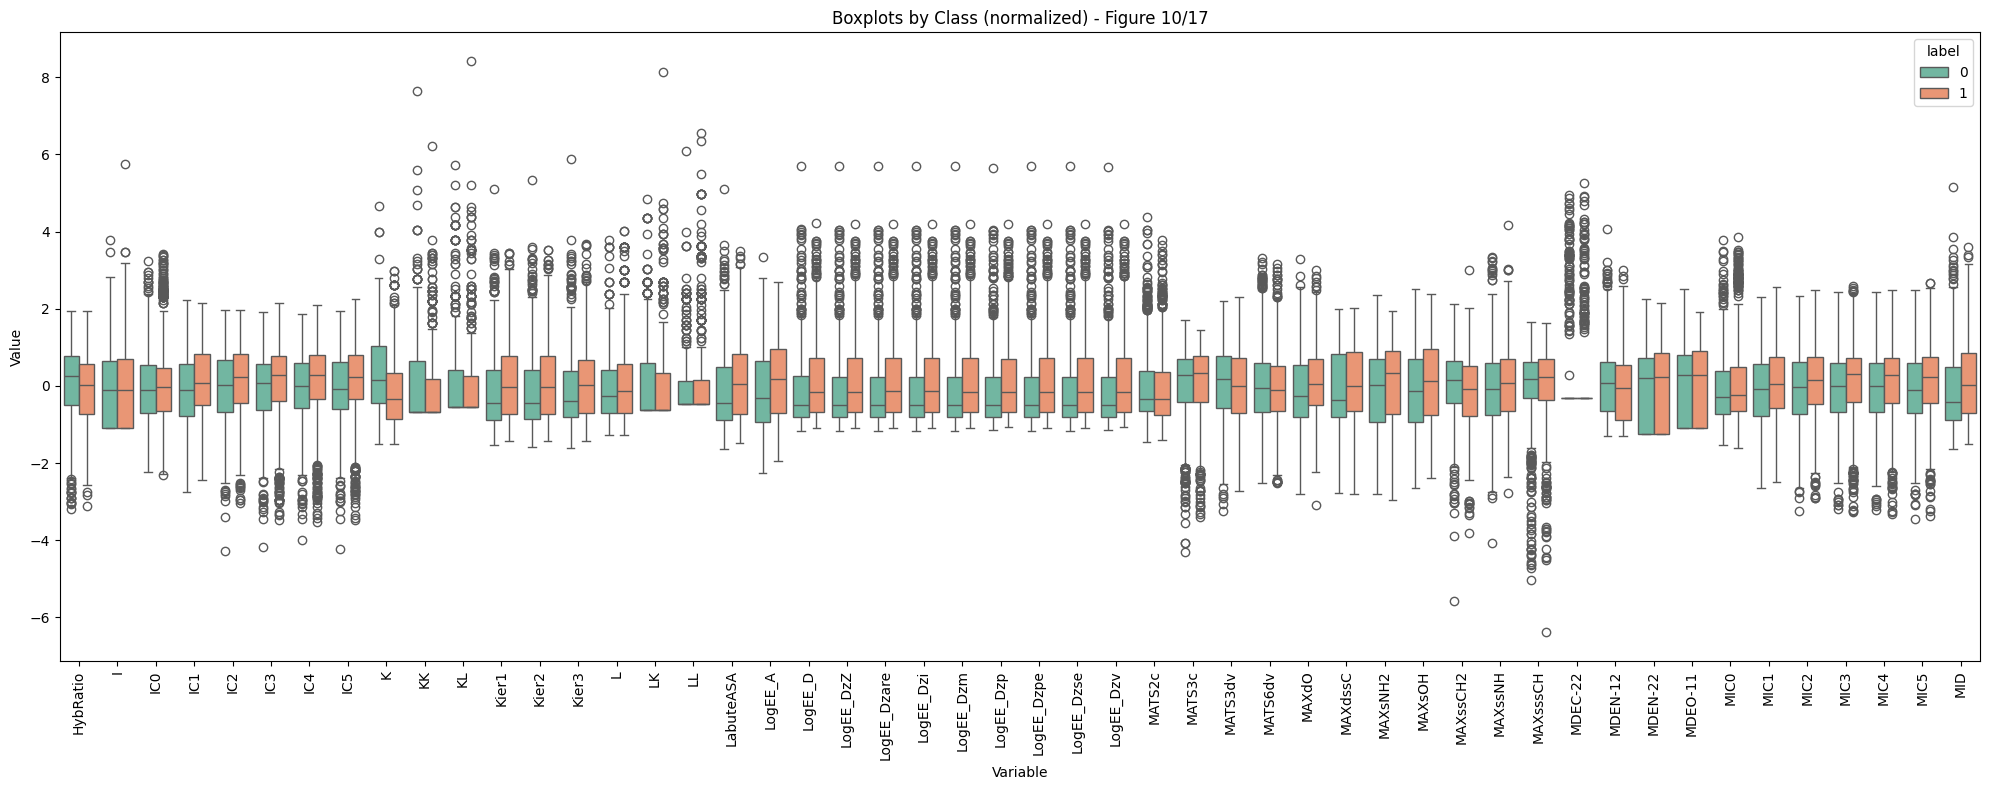

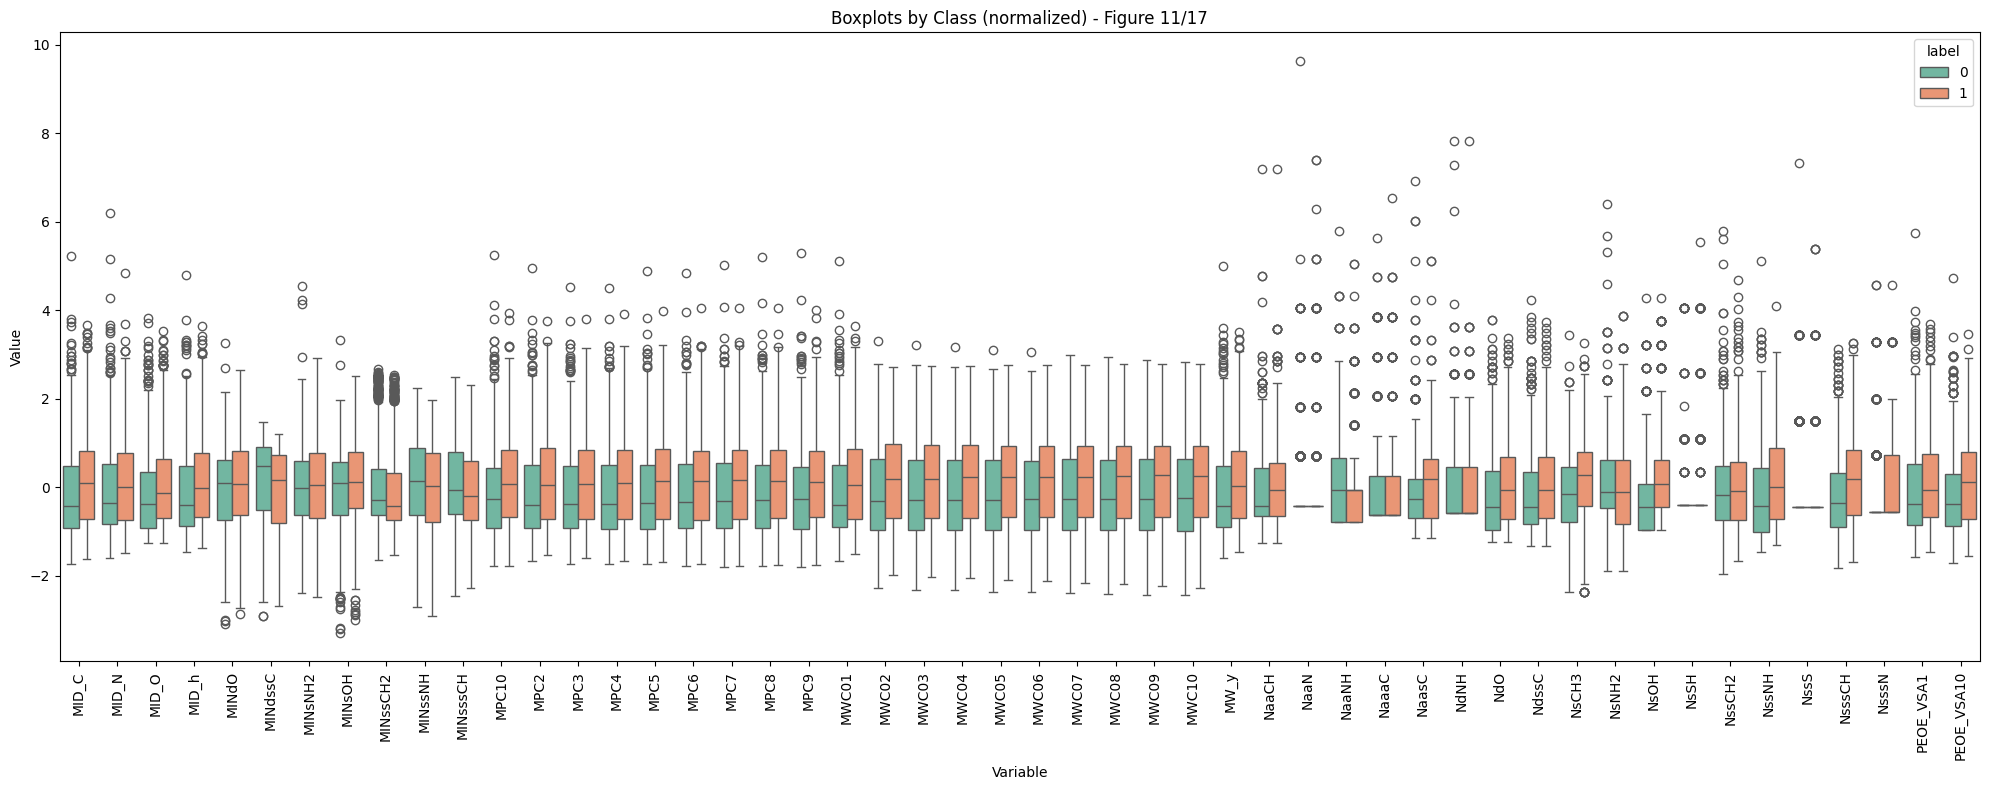

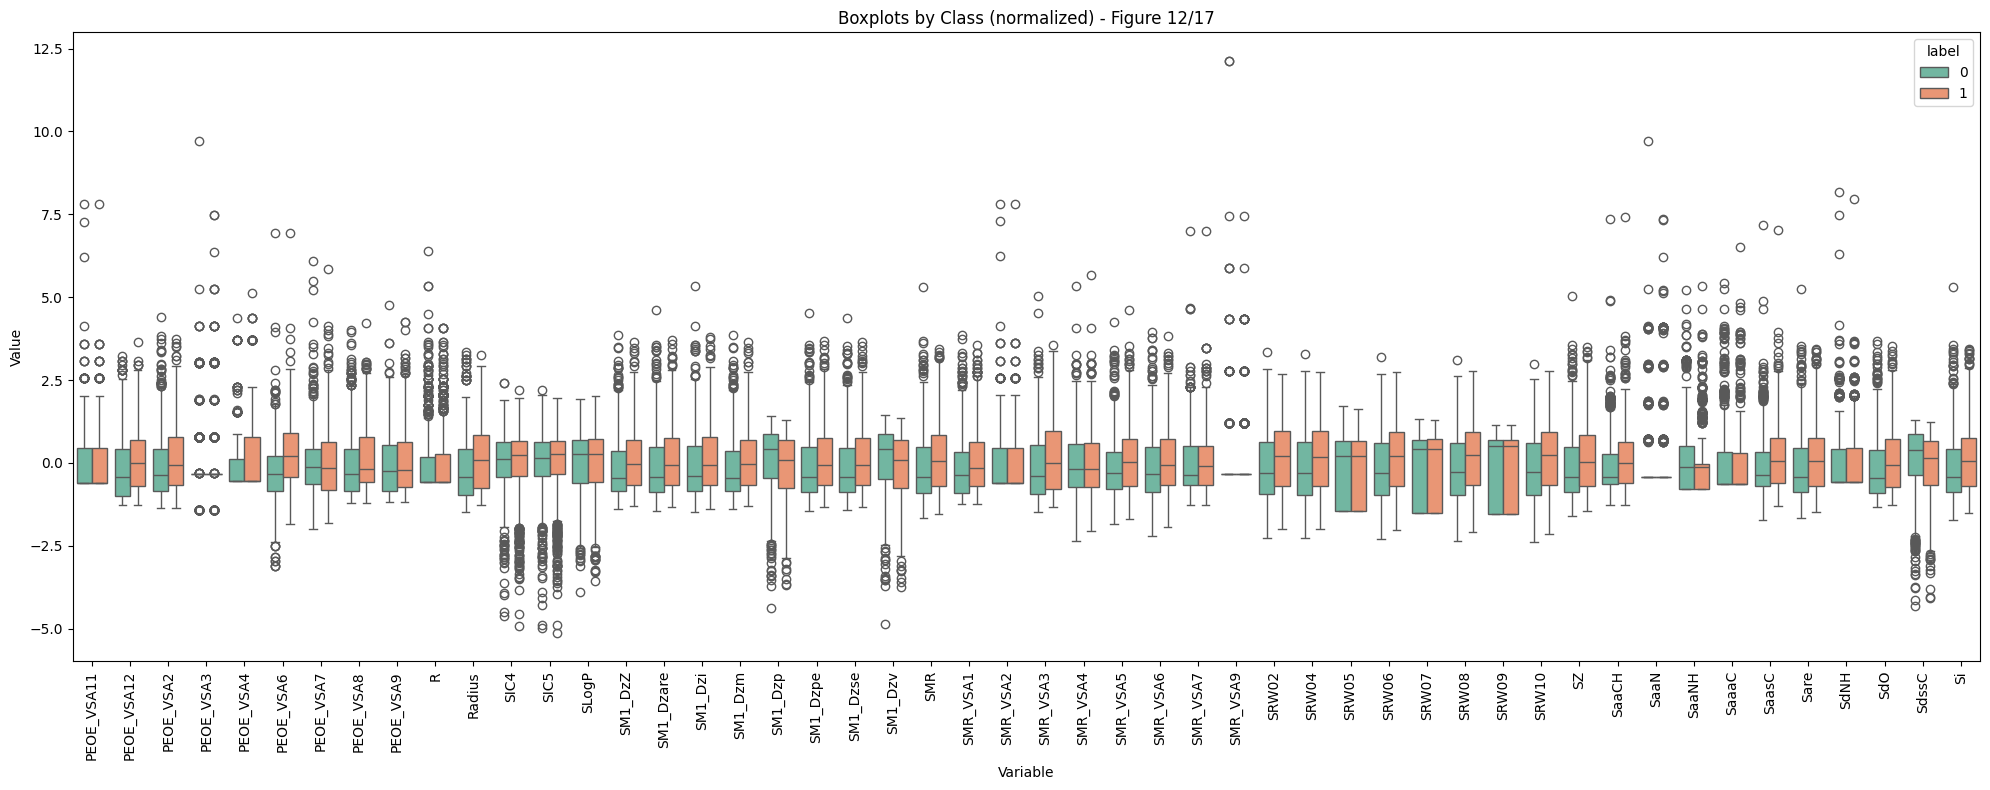

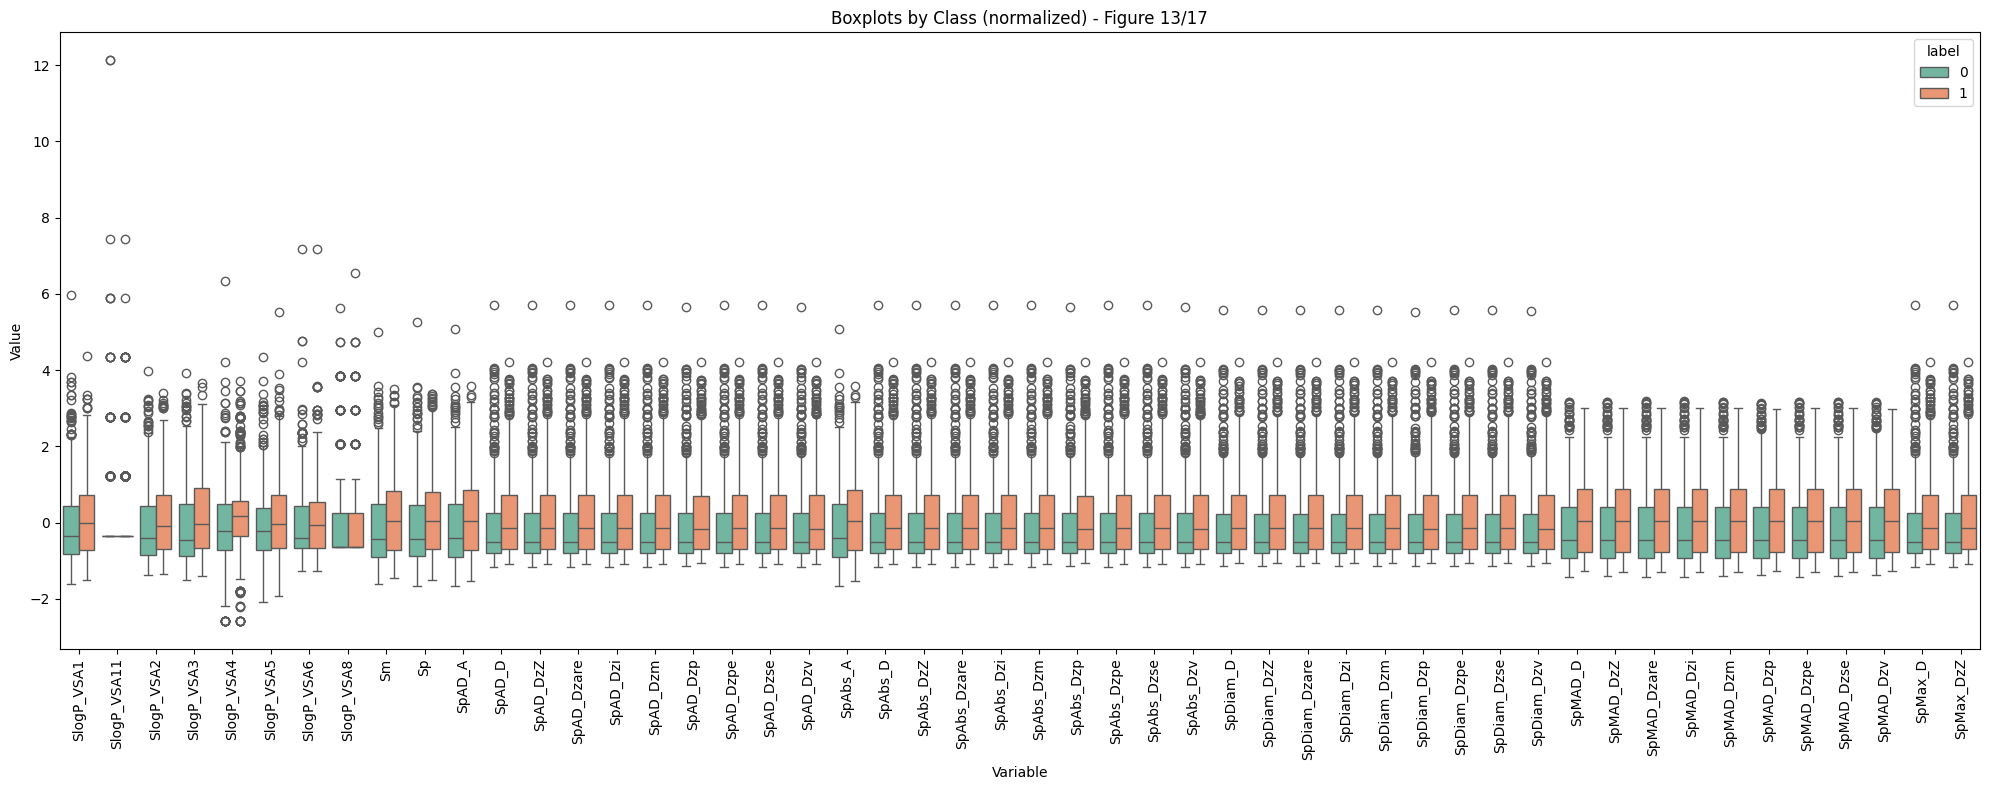

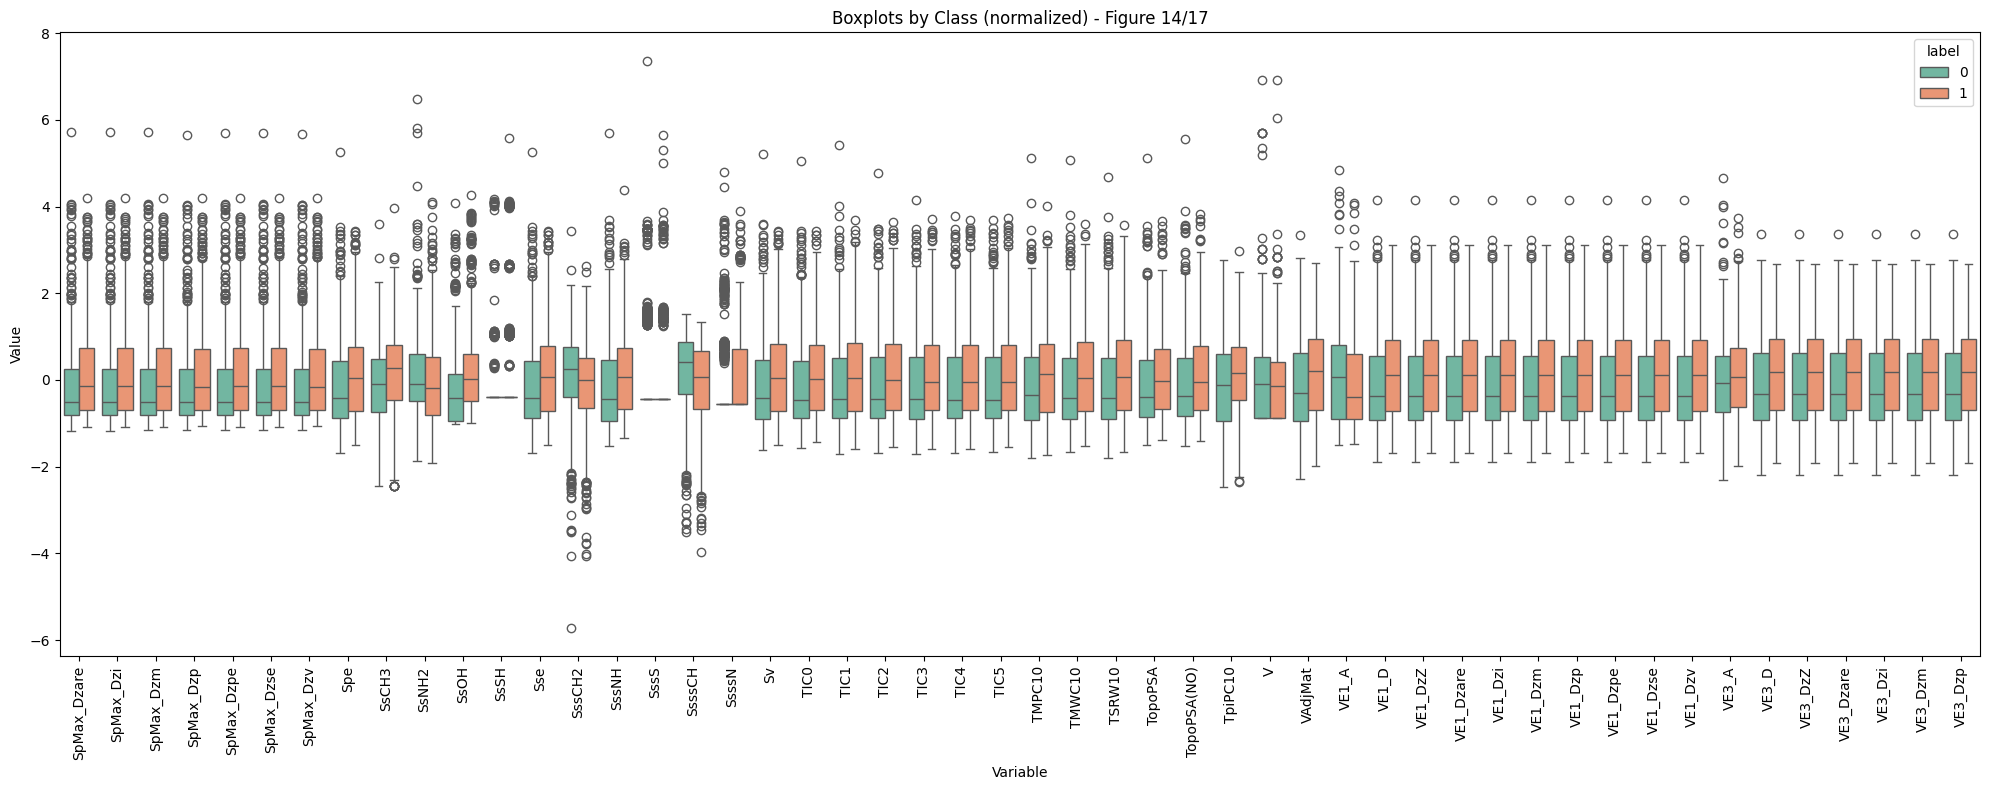

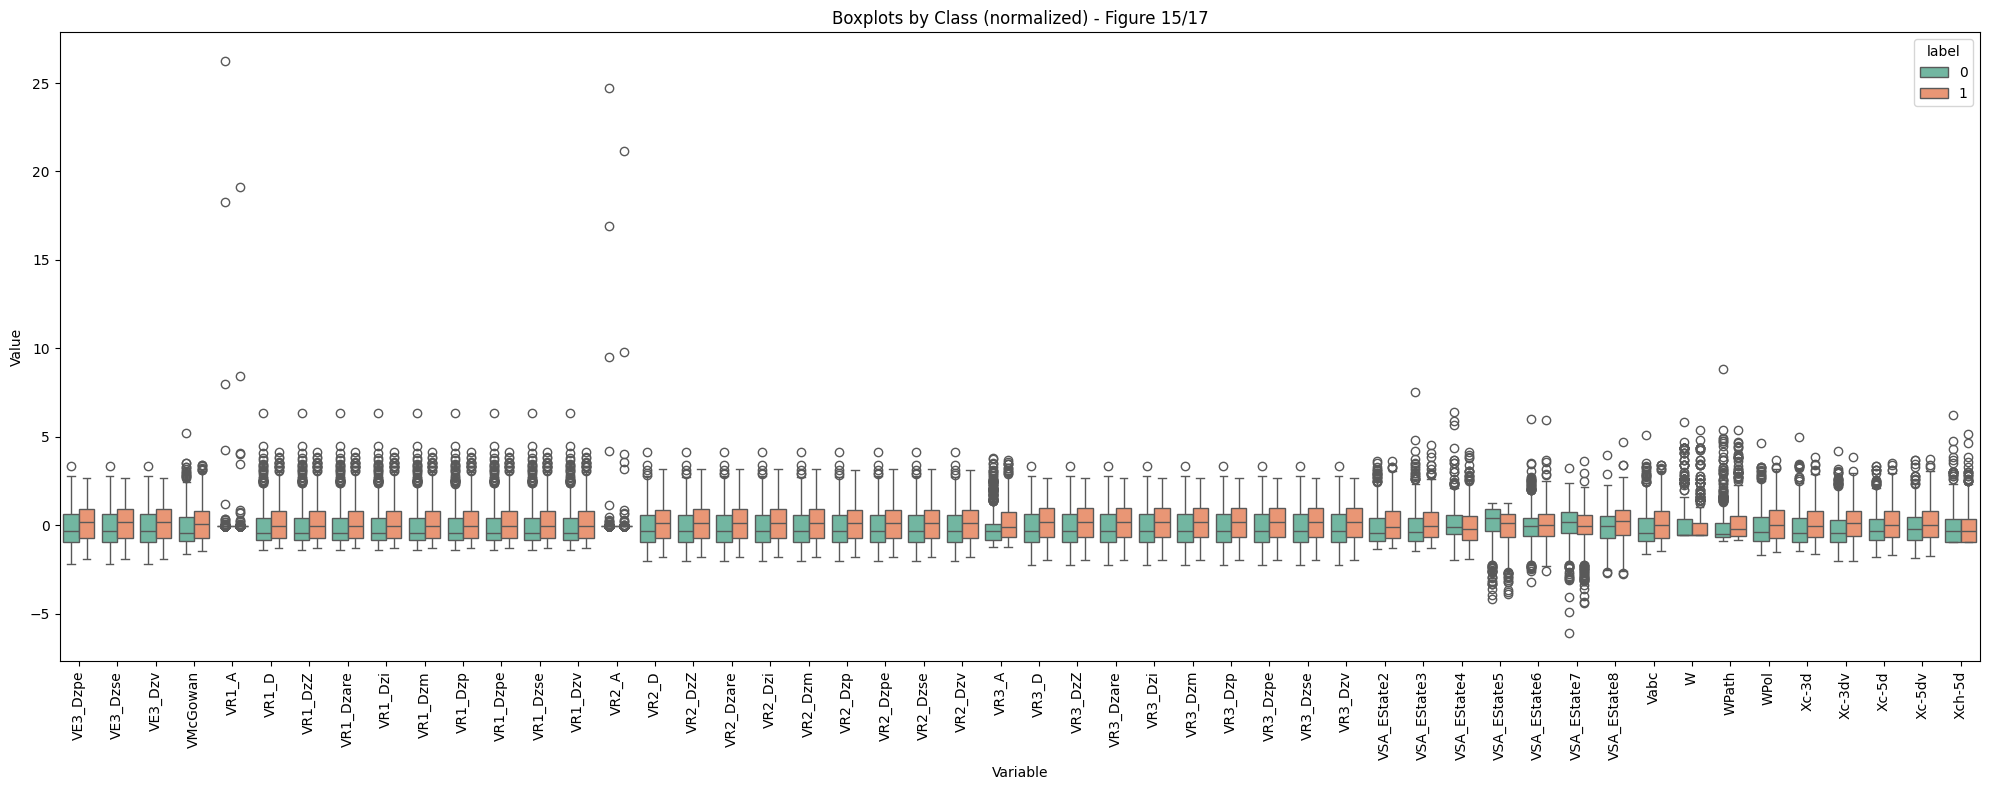

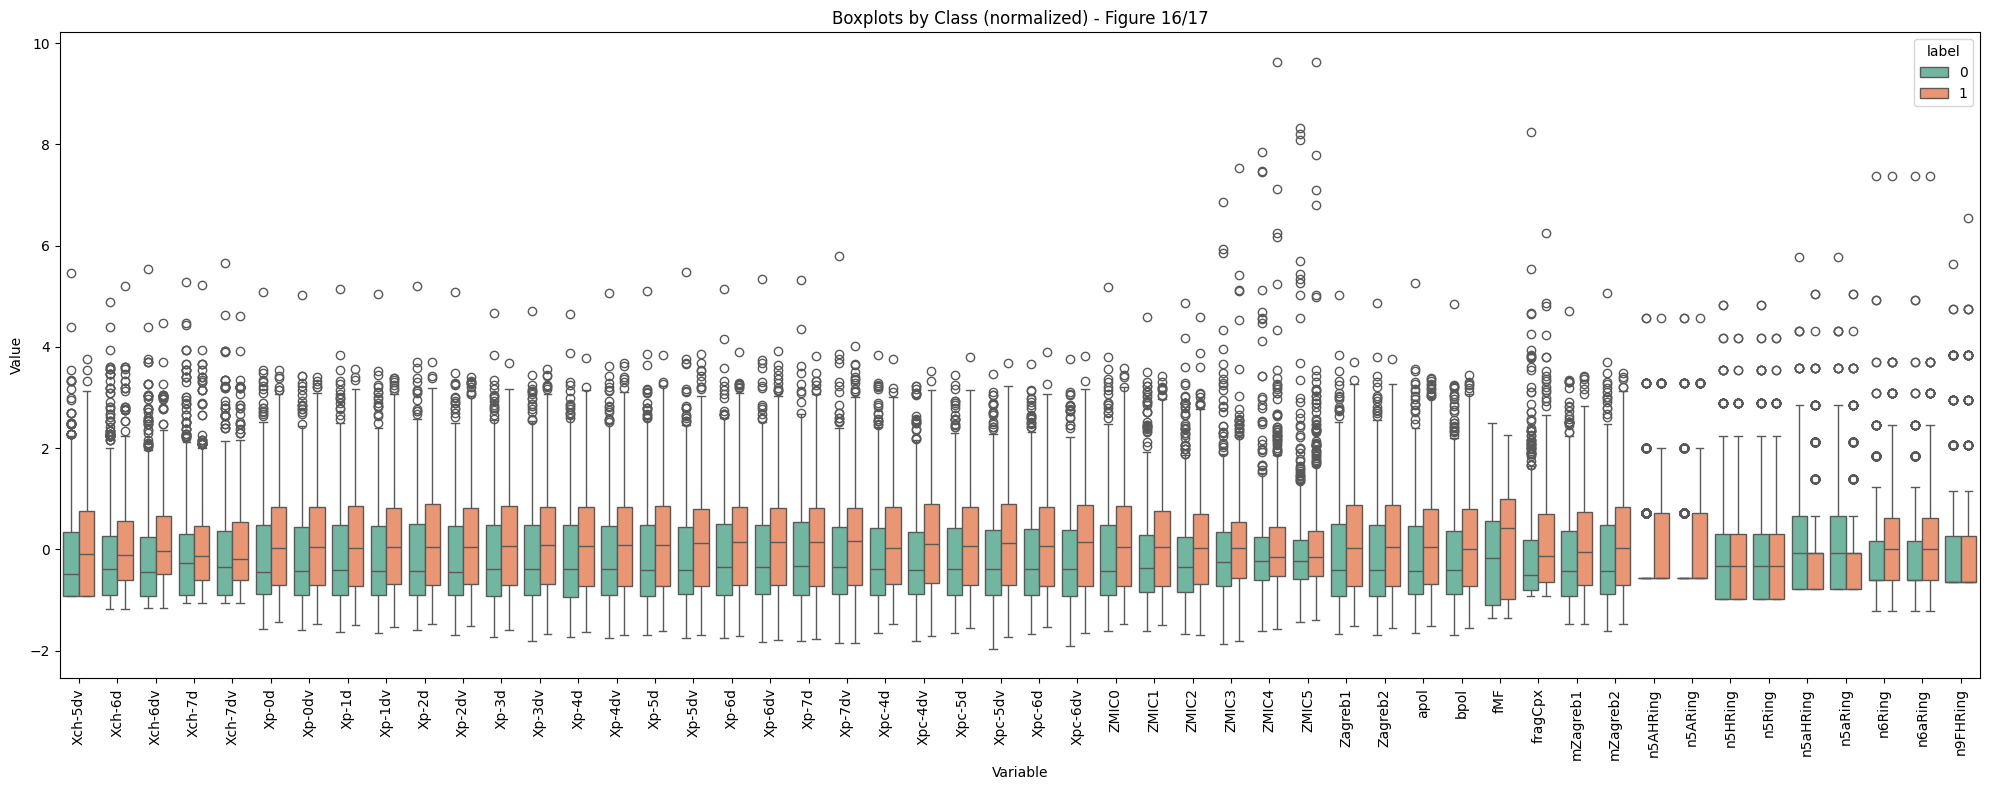

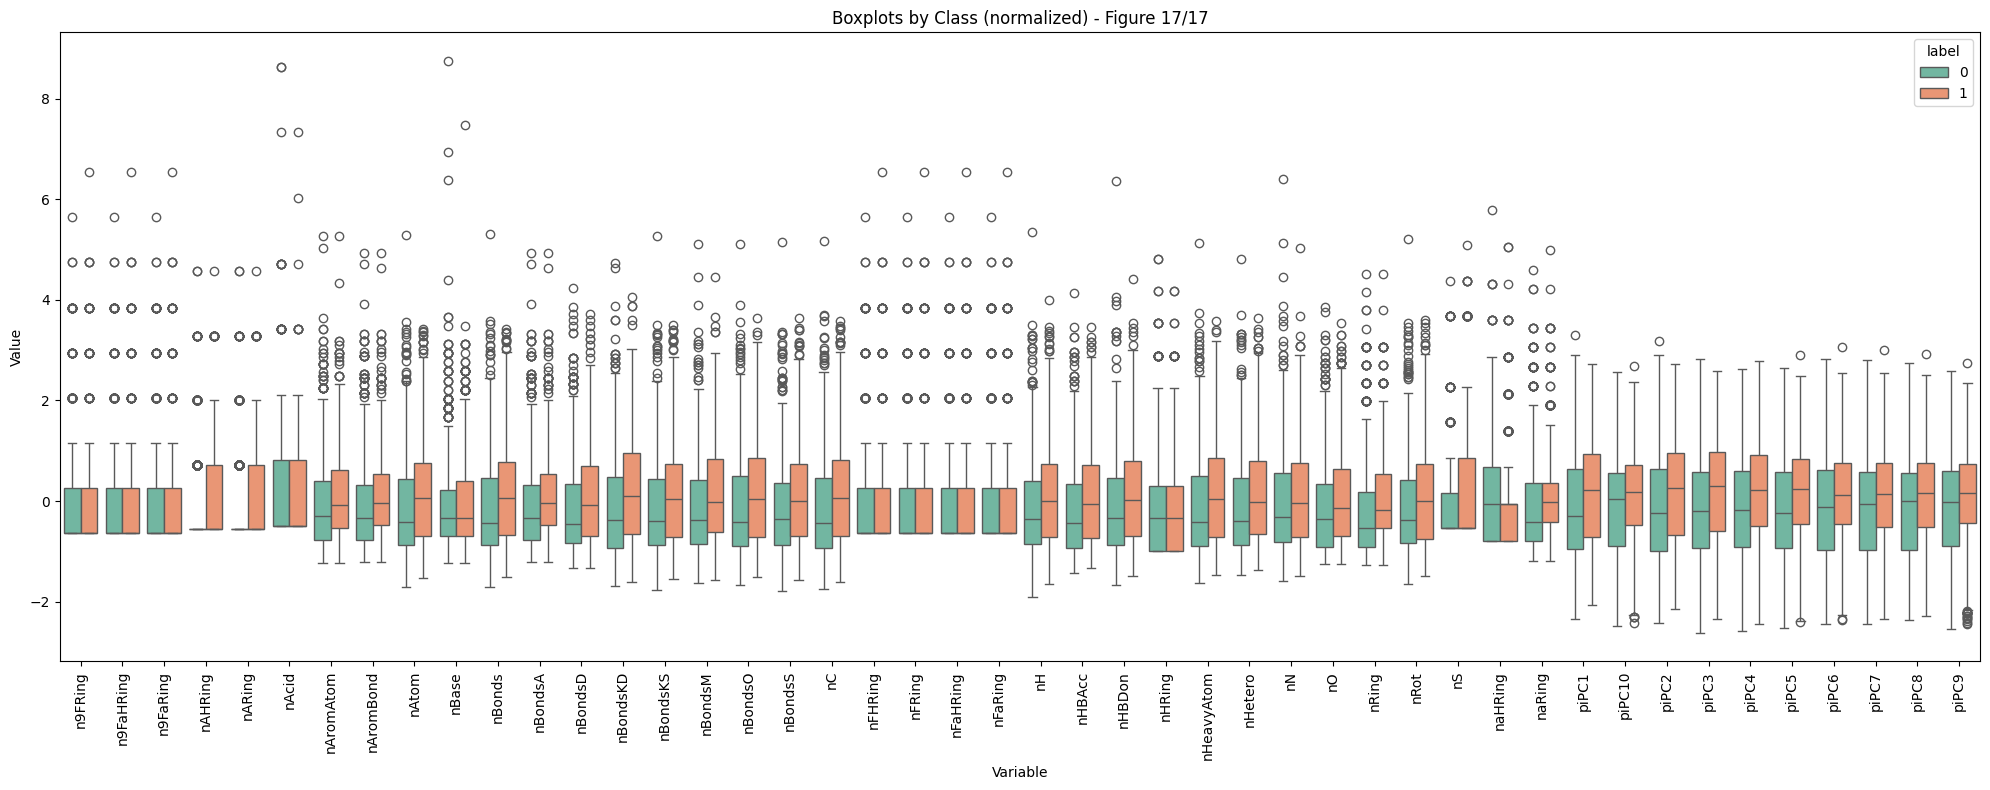

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Parámetros
label_col = 'label'
exclude_cols = ['μM', 'label', 'SEQUENCE']  # las que NO quieres normalizar
std_threshold = 0.05
vars_per_fig = 50


df = df_filtered
# 1️⃣ Filtrar columnas numéricas y aplicar el umbral de desviación estándar
numeric_cols = df.select_dtypes(include=['number']).columns.difference(exclude_cols)
filtered_vars = [col for col in numeric_cols if df[col].std() >= std_threshold]

# 2️⃣ Normalizar solo las columnas filtradas
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[filtered_vars] = scaler.fit_transform(df[filtered_vars])

# 3️⃣ Graficar en grupos de 50 variables
for i in range(0, len(filtered_vars), vars_per_fig):
    subset_vars = filtered_vars[i:i+vars_per_fig]
    melted = df_scaled.melt(id_vars=[label_col], value_vars=subset_vars,
                            var_name='Variable', value_name='Value')
    
    plt.figure(figsize=(20, 8))
    sns.boxplot(data=melted, x='Variable', y='Value', hue=label_col, palette='Set2')
    plt.xticks(rotation=90)
    plt.title(f'Boxplots by Class (normalized) - Figure {i//vars_per_fig + 1}/{-(-len(filtered_vars)//vars_per_fig)}')
    plt.tight_layout()
    plt.show()


/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_1401/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


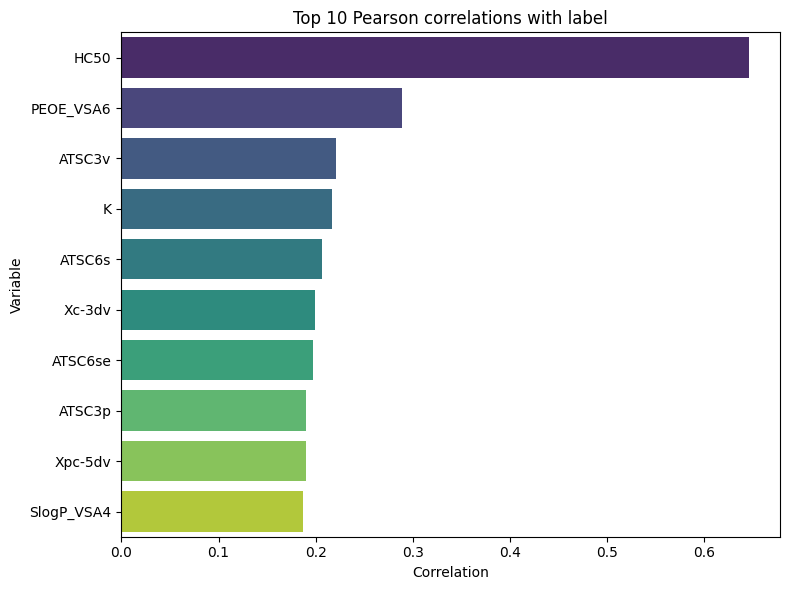

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_1401/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


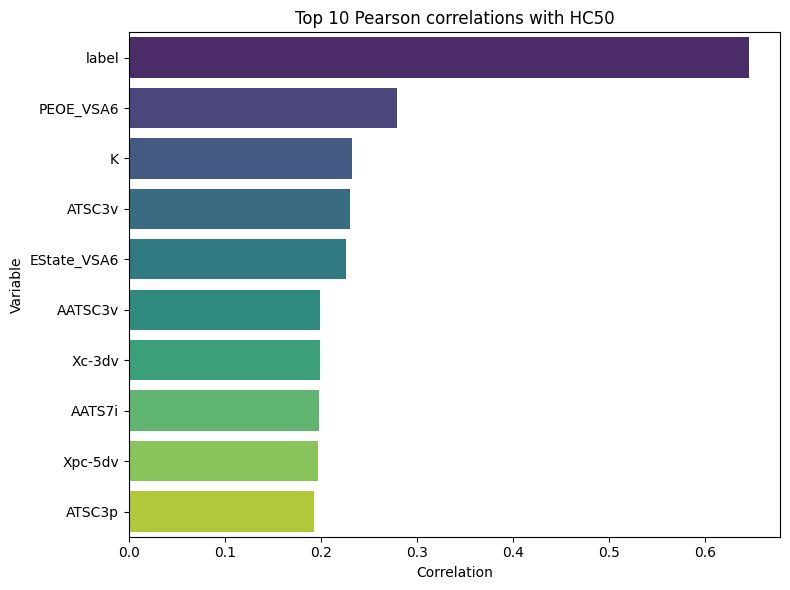

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_1401/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


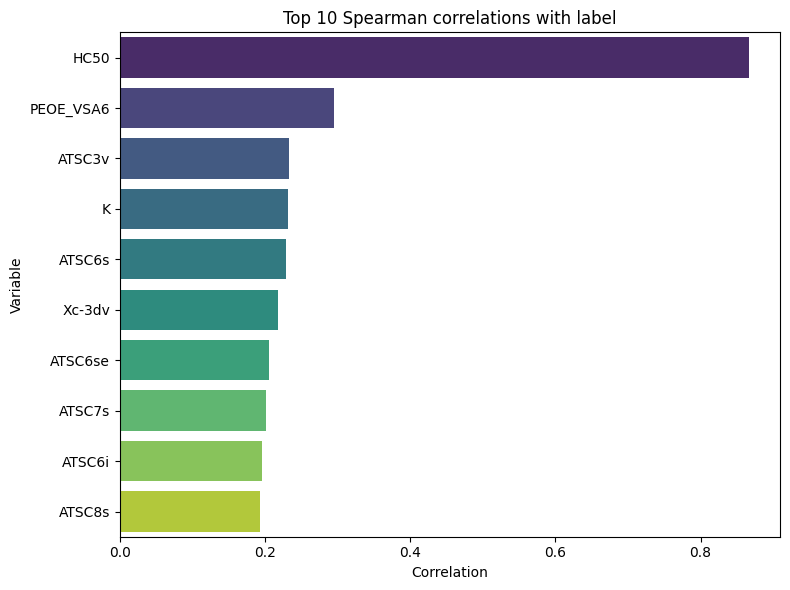

/var/folders/lk/smbwpztx1vv0c6ddmx410d780000gn/T/ipykernel_1401/164498092.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


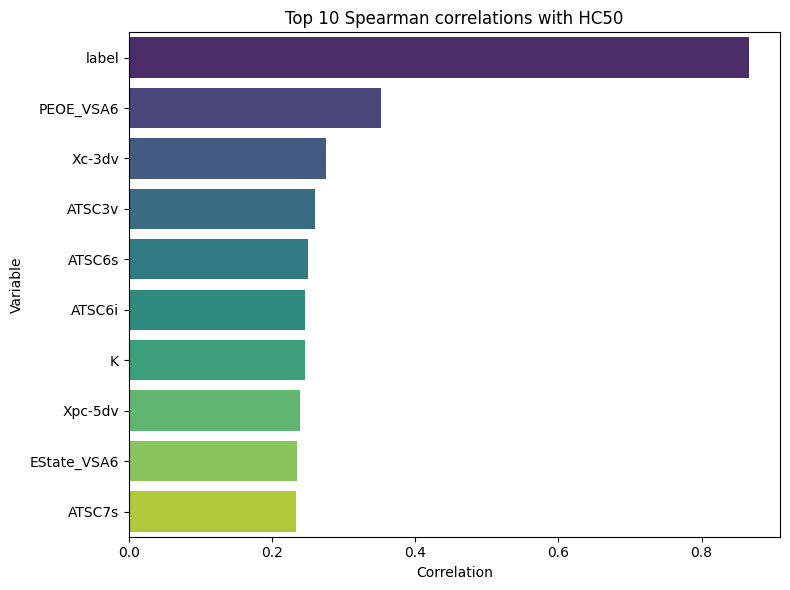

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = df_filtered
df = df.rename(columns={'μM': 'HC50'})

# Variables a excluir del análisis
exclude_cols = ['SEQUENCE']
target_class = 'label'
target_hc50 = 'HC50' if 'HC50' in df.columns else None

# Seleccionar solo columnas numéricas
numeric_df = df.drop(columns=exclude_cols).select_dtypes(include=['number'])

# Calcular correlaciones
corr_pearson = numeric_df.corr(method='pearson')
corr_spearman = numeric_df.corr(method='spearman')

def plot_top_corr(corr_matrix, target, method_name):
    # Ordenar por valor absoluto y quitar el target mismo
    top_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
    plt.title(f"Top 10 {method_name} correlations with {target}")
    plt.xlabel("Correlation")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

# Pearson
plot_top_corr(corr_pearson, target_class, 'Pearson')
if target_hc50:
    plot_top_corr(corr_pearson, target_hc50, 'Pearson')

# Spearman
plot_top_corr(corr_spearman, target_class, 'Spearman')
if target_hc50:
    plot_top_corr(corr_spearman, target_hc50, 'Spearman')


In [46]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, mode

# Filtrar solo variables numéricas, excluyendo la columna 'label'
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('label')

# Lista para almacenar resultados
results = []

# Recorrer cada variable numérica
for col in numeric_cols:
    class0 = df[df['label'] == 0][col].dropna()
    class1 = df[df['label'] == 1][col].dropna()
    
    # Estadísticas para clase 0
    mean0 = class0.mean()
    median0 = class0.median()
    mode0 = mode(class0, keepdims=True).mode[0] if len(class0) > 0 else np.nan
    q1_0 = class0.quantile(0.25)
    q3_0 = class0.quantile(0.75)
    shapiro_p0 = shapiro(class0)[1] if len(class0) >= 3 else np.nan
    
    # Estadísticas para clase 1
    mean1 = class1.mean()
    median1 = class1.median()
    mode1 = mode(class1, keepdims=True).mode[0] if len(class1) > 0 else np.nan
    q1_1 = class1.quantile(0.25)
    q3_1 = class1.quantile(0.75)
    shapiro_p1 = shapiro(class1)[1] if len(class1) >= 3 else np.nan
    
    # Levene test para varianzas
    levene_p = levene(class0, class1)[1] if len(class0) >= 2 and len(class1) >= 2 else np.nan
    
    # Guardar resultados
    results.append({
        'Variable': col,
        
        'Mean_Class0': mean0, 'Median_Class0': median0, 'Mode_Class0': mode0, 'Q1_Class0': q1_0, 'Q3_Class0': q3_0, 'ShapiroP_Class0': shapiro_p0,
        'Mean_Class1': mean1, 'Median_Class1': median1, 'Mode_Class1': mode1, 'Q1_Class1': q1_1, 'Q3_Class1': q3_1, 'ShapiroP_Class1': shapiro_p1,
        
        'LeveneP': levene_p
    })

# Convertir a DataFrame
stats_df = pd.DataFrame(results)

# Mostrar primeras filas
stats_df.head(100)


,Variable,Mean_Class0,Median_Class0,Mode_Class0,Q1_Class0,Q3_Class0,ShapiroP_Class0,Mean_Class1,Median_Class1,Mode_Class1,Q1_Class1,Q3_Class1,ShapiroP_Class1,LeveneP
0,HC50,297.894889,200.000000,200.000000,140.000000,400.000000,7.315783e-30,38.652043,32.000000,64.000000,12.250000,64.000000,7.922807e-20,2.427395e-73
1,A,0.087021,0.066667,0.000000,0.000000,0.125000,7.892684e-28,0.078013,0.066667,0.000000,0.000000,0.125000,4.546908e-26,2.506101e-02
2,AATS0Z,20.987600,20.880448,19.166023,20.045814,21.759289,2.852991e-16,21.333513,21.086758,19.793103,20.295152,21.787625,4.208969e-24,2.450721e-04
3,AATS0are,6.198397,6.191268,6.058718,6.134088,6.264055,3.444131e-04,6.203904,6.199216,6.163934,6.141060,6.259767,3.464996e-06,6.351019e-01
4,AATS0d,2.761096,2.741071,2.659649,2.673850,2.822772,1.364103e-15,2.782446,2.769231,2.620690,2.708492,2.858192,3.591810e-05,3.356040e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AATSC1m,-0.533458,-0.496768,-1.653063,-0.696815,-0.249742,7.899053e-26,-0.660066,-0.497420,-0.660222,-0.733165,-0.229926,6.551164e-32,6.269894e-06
96,AATSC1v,1.309870,1.162014,1.397436,0.693466,1.736749,1.119349e-15,1.193222,1.113477,-0.244961,0.646143,1.619635,8.213697e-10,1.189923e-01
97,AATSC2Z,0.198052,0.227472,0.323543,0.049624,0.359948,1.540550e-07,0.196964,0.245532,0.542897,0.083666,0.375315,9.232131e-16,3.218970e-01
98,AATSC2dv,0.451863,0.479076,0.461755,0.392081,0.526230,7.692024e-19,0.435465,0.461217,0.506417,0.366491,0.510639,5.953689e-15,9.419817e-01


1. Medidas de tendencia central
Media (mean) → promedio de los valores.

Mediana (median) → punto que divide el conjunto en dos mitades.

Moda (mode) → valor más frecuente (puede que no exista si todos son distintos).

2. Cuartiles
Q1 → 25% de los datos están por debajo.

Q3 → 75% de los datos están por debajo.

Esto nos ayuda a ver la dispersión y posibles sesgos.

3. Normalidad: Shapiro–Wilk test
Hipótesis nula: los datos vienen de una distribución normal.

Si p > 0.05 → no se rechaza normalidad (datos normales).

Si p ≤ 0.05 → se rechaza normalidad (datos no normales).

4. Homogeneidad de varianzas: Levene’s test
Compara varianzas entre clases.

Si p > 0.05 → varianzas iguales.

Si p ≤ 0.05 → varianzas diferentes.

In [47]:
# Filtrar variables con p >= 0.05 en cualquiera de las dos clases

print(stats_df.info())

stats_df = stats_df.drop_duplicates()

print(stats_df.info())

normal_vars = stats_df[
    (stats_df['ShapiroP_Class0'] >= 0.05) | 
    (stats_df['ShapiroP_Class1'] >= 0.05)
]['Variable'].tolist()

print("Variables con distribución normal en al menos una clase:")
print(normal_vars)
print(len(normal_vars))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Variable         847 non-null    object 
 1   Mean_Class0      847 non-null    float64
 2   Median_Class0    847 non-null    float64
 3   Mode_Class0      847 non-null    float64
 4   Q1_Class0        847 non-null    float64
 5   Q3_Class0        847 non-null    float64
 6   ShapiroP_Class0  847 non-null    float64
 7   Mean_Class1      847 non-null    float64
 8   Median_Class1    847 non-null    float64
 9   Mode_Class1      847 non-null    float64
 10  Q1_Class1        847 non-null    float64
 11  Q3_Class1        847 non-null    float64
 12  ShapiroP_Class1  847 non-null    float64
 13  LeveneP          847 non-null    float64
dtypes: float64(13), object(1)
memory usage: 92.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 14 colum

In [48]:
from scipy.stats import ttest_ind
import pandas as pd

# Seleccionamos solo las columnas numéricas excluyendo la clase
numeric_cols = df.select_dtypes(include='number').columns.drop('label')

# Lista para guardar resultados
t_results = []

# Iterar sobre cada variable y hacer el t-test
for col in numeric_cols:
    class0 = df[df['label'] == 0][col].dropna()
    class1 = df[df['label'] == 1][col].dropna()
    
    t_stat, p_val = ttest_ind(class0, class1, equal_var=False)  # Welch's t-test
    t_results.append({
        'Variable': col,
        'T_statistic': t_stat,
        'P_value': p_val,
        'Significant': p_val < 0.05  # True si p < 0.05
    })

# Convertir a DataFrame
t_results_df = pd.DataFrame(t_results)

# Ordenar por P_value
t_results_df = t_results_df.sort_values(by='P_value')

# Mostrar las más significativas
print(t_results_df.head(20))


# Filtrar solo las significativas
significant_vars = t_results_df[t_results_df['Significant']]

print("Top 10 most significant variables:")
print(significant_vars.head(10))


        Variable  T_statistic        P_value  Significant
0           HC50    34.133321  9.126537e-161         True
556    PEOE_VSA6   -12.041324   5.138538e-32         True
289       ATSC3v     9.057275   3.834002e-19         True
459            K     8.860820   2.073508e-18         True
323       ATSC6s     8.439397   7.049368e-17         True
747       Xc-3dv    -8.128449   8.628865e-16         True
324      ATSC6se     8.053489   1.562668e-15         True
285       ATSC3p     7.752743   1.591991e-14         True
775      Xpc-5dv    -7.712219   2.173507e-14         True
605   SlogP_VSA4    -7.588611   5.466502e-14         True
437       GATS8d     7.505827   1.021414e-13         True
322      ATSC6pe     7.496643   1.080947e-13         True
777      Xpc-6dv    -7.437446   1.675473e-13         True
315     ATSC6are     7.313520   4.103261e-13         True
773      Xpc-4dv    -7.296165   4.658611e-13         True
107      AATSC3v     7.245017   6.702916e-13         True
319       ATSC

In [49]:
import pandas as pd
import numpy as np

def remove_highly_correlated(df, method='pearson', threshold=0.75):
    """
    Removes highly correlated features from a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame with numeric features.
        method (str): 'pearson' or 'spearman'.
        threshold (float): Correlation threshold above which to remove variables.
    
    Returns:
        df_filtered (pd.DataFrame): DataFrame without highly correlated features.
        removed_features (list): List of removed features.
    """
    corr_matrix = df.corr(method=method).abs()
    
    # Mask upper triangle to avoid duplicate checks
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    removed_features = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered = df.drop(columns=removed_features)
    return df_filtered, removed_features

# Ejemplo de uso (Pearson)
numeric_df = df.select_dtypes(include='number').drop(columns=['label'])  # sin la clase
df_pearson, removed_pearson = remove_highly_correlated(numeric_df, method='pearson', threshold=0.75)

# Ejemplo de uso (Spearman)
df_spearman, removed_spearman = remove_highly_correlated(numeric_df, method='spearman', threshold=0.75)

print(f"Removed with Pearson: {len(removed_pearson)} variables")
print(f"Removed with Spearman: {len(removed_spearman)} variables")


# print(df_pearson.info())
# print(df_spearman.info())

df_final = df_spearman.copy()
df_final["label"] = df["label"]

# Guardar resultado
result_folder = "../data/result"
path = f"{result_folder}/df_final.csv"
df_final.to_csv(path, index=False)

print("DataFrame final guardado con label incluida en:", path)

Removed with Pearson: 778 variables
Removed with Spearman: 772 variables
DataFrame final guardado con label incluida en: ../data/result/df_final.csv
